<a href="https://colab.research.google.com/github/Cesarbmm/Aplicacion-Personal/blob/main/ProyectoV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de IA: Clasificación de Prendas de vestir

# 1. Introducción

Este proyecto usa un modelo de Deep Learning para la clasificación automática de prendas de vestir, usando un dataset con más de 5000 imágenes etiquetadas.
La idea es explorar diferentes arquitecturas de redes neuronales convolucionales (CNN) y comparar su desempeño mediante métricas estándar de clasificación.

In [ ]:
!pip install Pillow
!pip install highlight-text

In [ ]:
# --- Importación de Librerías ---

# Biblioteca para operaciones matemáticas y manejo de arreglos
import numpy as np

# Biblioteca para manipulación de datos en forma de tablas (DataFrames)
import pandas as pd

# Librería para visualización estadística avanzada
import seaborn as sns

# Framework de aprendizaje profundo utilizado para construir y entrenar redes neuronales
import tensorflow as tf

# Biblioteca principal de gráficos en Python
import matplotlib.pyplot as plt

# Para crear formas y parches en las gráficas
import matplotlib.patches as mpatches

# Para controlar o ignorar ciertos tipos de advertencias en la ejecución
import warnings

# Librería para realizar solicitudes a URLs (descargas, accesos remotos, etc.)
import urllib

# Componentes de TensorFlow para modelos y entrenamiento
from tensorflow import keras
from keras.optimizers import SGD  # Optimizador Gradiente Descendente Estocástico

# Herramientas de validación cruzada y división de datos
from sklearn.model_selection import KFold, cross_val_score

# Métricas para clasificación, reportes y matriz de confusión
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Librería para resaltar texto dentro de gráficos
from highlight_text import fig_text

# Librería para abrir, cargar y procesar imágenes
from PIL import Image


# 2. Descripción del Dataset

El dataset contiene:

Imágenes: 5000 imágenes de prendas de vestir (formato: 28×28 o tamaño original según dataset).

CSV asociado:

image: ruta o nombre del archivo de imagen

sender_id: identificador del origen

label: etiqueta de la prenda

kids: valor binario indicando si es ropa infantil

Lista de clases utilizadas (fashion_list):
( T-shirt, pants, coat, sandals, etc.)

In [ ]:
# Clase para manejar colores en la impresión de texto en la terminal
class clr:
    start = '\033[94m'   # Color azul
    end = '\033[0m'      # Reset de color
    color = '\033[92m'   # Color verde

# --- Carga del conjunto de entrenamiento y prueba (Train & Test Set) ---

print(clr.start + '.:. Preparando Train-Test .:.' + clr.end)
print(clr.color + '*' * 29 + clr.end)

# Cargamos el dataset Fashion MNIST desde TensorFlow
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(clr.color + '*' * 29 + clr.end)

# --- Información sobre Train y Test ---
print(clr.start + '\n.:. Información de Train-Test .:.' + clr.end)
print(clr.color + '*' * 25)

# Información del conjunto de entrenamiento
print(clr.start + f'>> Train Set' + clr.end)
print(clr.end + f'\t.: Total de datos en Train set:' + clr.start, f'{X_train.shape[0]:,}')
print(clr.end + f'\t.: Total de etiquetas en Train set:' + clr.start, f'{y_train.shape[0]:,}')
print(clr.end + f'\t.: Total de columnas por imagen en Train set:' + clr.start, f'{X_train.shape[1]:,}')

# Información del conjunto de prueba
print('\n' + clr.start + f'>> Test Set' + clr.end)
print(clr.end + f'\t.: Total de datos en Test set:' + clr.start, f'{X_test.shape[0]:,}')
print(clr.end + f'\t.: Total de etiquetas en Test set:' + clr.start, f'{y_test.shape[0]:,}')
print(clr.end + f'\t.: Total de columnas por imagen en Test set:' + clr.start, f'{X_test.shape[1]:,}')



.:. Preparando Train-Test .:.
*****************************
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
*****************************

.:. Información de Train-Test .:.
*************************
>> Train Set
	.: Total de datos en Train set: 60,000
	.: Total de etiquetas en Train set: 60,000
	.: Total de columnas por imagen en Train set: 28

>> Test Set
	.: Total de datos en Test set: 10,000
	.: Total de etiquetas en Test set: 10,000
	.: Total de columnas por imagen en Test set: 28


In [ ]:
# --- Escalado de los valores de los píxeles ---
# Se normalizan los valores de los píxeles dividiéndolos para 255.
# Esto transforma cada valor a un rango de 0 a 1, lo cual ayuda al modelo a entrenar mejor.
X_train = X_train / 255.0
X_test = X_test / 255.0

# --- One-Hot Encoding de las variables objetivo ---
# Convierte las etiquetas numéricas (0–9) en vectores binarios.
# Ejemplo: la etiqueta 3 se convierte en [0,0,0,1,0,0,0,0,0,0]
# Esto es necesario para entrenar modelos de clasificación multiclase.
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)



# 3. Arquitectura del Modelo (Experiment Model 1 y 2)

##  **Experiment Model 1 – Arquitectura Base**

El primer modelo funciona como un **modelo base** o punto de referencia (*baseline*). Su arquitectura busca un equilibrio entre simplicidad y capacidad para aprender patrones esenciales del dataset.


### **1. Capas Convolucionales Iniciales**

Utilizar capas "Conv2D" al inicio permite que el modelo:

* Extraiga características locales como bordes, texturas, líneas y patrones simples.
* Construya progresivamente información más abstracta (curvaturas, formas, siluetas).
* Evite el uso de parámetros excesivos comparado con MLP tradicionales.

En clasificación de ropa, estas características visuales son claves para distinguir:

* mangas vs. tiras
* pliegues
* forma general de la prenda


### 2. MaxPooling (Reducción espacial)

Las capas "MaxPooling2D" se utilizan para:

* Reducir el tamaño espacial de las imágenes
* Conservar las características importantes
* Disminuir el costo computacional
* Hacer que el modelo sea más robusto a pequeñas variaciones y traslaciones


Esto permite que la red aprenda invariancia: si una prenda está ligeramente corrida o inclinada, aún debe ser reconocida.



### 3. Dropout para Regularización

Se incluyen capas "Dropout" al final del feature extractor y antes del clasificador denso.

Su función es:

* Reducir el **overfitting**
* Evitar que las neuronas dependan excesivamente unas de otras
* Permitir que el modelo generalice mejor a datos nuevos


Como hay un dataset de 5000 imágenes, el riesgo de sobreajuste es alto. Dropout asegura estabilidad.


### 4. Capa Fully Connected Final

Después de extraer características, el modelo necesita una capa densa que actúe como clasificador.

Esta capa:

* Recibe las features aprendidas
* Calcula probabilidades de cada clase
* Usa activación "softmax" para obtener etiquetado multicategoría

Es aquí donde el modelo decide si la imagen es:

* T-shirt
* Pants
* Coat
* Dress
* Etc.

In [ ]:
# --- Construcción del Modelo Básico ---
# Se crea un modelo secuencial (capa tras capa) para clasificar imágenes de 28x28 píxeles.
model_1 = tf.keras.Sequential([
    # Convierte la imagen 2D (28x28) en un vector de 784 valores.
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Capa densa (fully connected) con 128 neuronas y activación ReLU.
    # Esta capa aprende patrones intermedios de la imagen.
    tf.keras.layers.Dense(128, activation='relu'),

    # Capa de salida con 10 neuronas (una por cada clase del dataset Fashion MNIST)
    # y función softmax para obtener probabilidades.
    tf.keras.layers.Dense(10, activation='softmax')
])

# --- Modelo 1: Resumen del Modelo Básico ---
print(clr.start + '.:. Resumen del Modelo Básico .:.' + clr.end)
print(clr.color + '*' * 65 + clr.end)

# Imprime la estructura del modelo, número de parámetros y forma de las capas
model_1.summary()


.:. Resumen del Modelo Básico .:.
*****************************************************************


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

El Model 1 sirve para:

* Obtener un punto base de desempeño
* Probar si el dataset está bien procesado
* Verificar si la arquitectura simple es suficiente
* Comparar con modelos más complejos

Su función dentro del proyecto es **establecer una línea base** para justificar mejoras posteriores.



In [ ]:
# Función para entrenar el modelo usando validación cruzada (K-Fold)
def fitting_model(model, model_name, epochs):
    histories, scores, losses = [], [], []

    # Recorremos cada “fold” del K-Fold
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
        print(clr.color + '\n' + '*' * 30 + clr.end)
        print(clr.start + f'>> Fold {fold+1} - {model_name} <<' + clr.end)
        print(clr.color + '*' * 30 + clr.end)

        # Seleccionamos los datos de entrenamiento y validación correspondientes a este fold
        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

        # Reajuste de la forma de los datos si se entrena un modelo CNN (por ahora es un placeholder)
        if model_name == "CNN Model":  # Se activará cuando uses un modelo convolucional
            X_train_fold = X_train_fold.reshape(X_train_fold.shape[0], 28, 28, 1)
            X_val_fold = X_val_fold.reshape(X_val_fold.shape[0], 28, 28, 1)

        # Entrenamiento del modelo en el fold actual
        history = model.fit(
            X_train_fold, y_train_fold,
            epochs=epochs,
            validation_data=(X_val_fold, y_val_fold),
            verbose=0
        )
        histories.append(history)

        # Evaluamos el modelo con el conjunto de validación del fold
        loss, score = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        losses.append(loss)
        scores.append(score)

        print(clr.end + f'\t.:. Val Loss: {loss:.4f}' + clr.start)
        print(clr.end + f'\t.:. Val Accuracy: {score:.4f}' + clr.start)

    # Resultados promediados tras completar todos los folds
    print(clr.color + '\n' + '*' * 30 + clr.end)
    print(clr.start + f'>> Promedio de métricas de {model_name} <<' + clr.end)
    print(clr.color + '*' * 30 + clr.end)
    print(clr.end + f'\t.:. Pérdida Promedio (Val Loss): {np.mean(losses):.4f}' + clr.start)
    print(clr.end + f'\t.:. Precisión Promedio (Val Accuracy): {np.mean(scores):.4f}' + clr.start)

    # Se devuelve: último history, promedio de accuracy, lista de pérdidas, lista de accuracies y todos los histories
    return history, np.mean(scores), losses, scores, histories


# Función para realizar predicciones en el conjunto de prueba
def create_prediction(model, model_name, target_size):
    print(clr.start + f'\n.:. Creando Predicciones para {model_name} .:.' + clr.end)
    print(clr.color + '*' * target_size + clr.end)

    # Se rehace la forma del test set si es CNN
    X_test_reshaped = X_test
    if model_name == "CNN Model":  # Placeholder para futuros modelos CNN
        X_test_reshaped = X_test.reshape(X_test.shape[0], 28, 28, 1)

    # Generación de predicciones
    y_pred = model.predict(X_test_reshaped)

    print(clr.color + '*' * target_size + clr.end)
    return y_pred


# Función para evaluar el modelo usando el conjunto de prueba completo
def evaluate_model(model, model_name, target_size):
    print(clr.start + f'\n.:. Evaluando {model_name} en Test .:.' + clr.end)
    print(clr.color + '*' * target_size + clr.end)

    # Reajuste si es una CNN
    X_test_reshaped = X_test
    if model_name == "CNN Model":  # Placeholder
        X_test_reshaped = X_test.reshape(X_test.shape[0], 28, 28, 1)

    # Evaluación del modelo en los datos de prueba
    test_loss, test_acc = model.evaluate(X_test_reshaped, y_test, verbose=0)

    print(clr.end + f'\t.:. Test Loss: {test_loss:.4f}' + clr.start)
    print(clr.end + f'\t.:. Test Accuracy: {test_acc:.4f}' + clr.start)
    print(clr.color + '*' * target_size + clr.end)

    return test_loss, test_acc


In [ ]:
# --- Modelo Básico - Parámetros ---
# Se compila el modelo especificando:
# - Optimizador: 'adam'
# - Función de pérdida: entropía cruzada categórica (para clasificación multiclase)
# - Métrica a evaluar: precisión (accuracy)
model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- Parámetros de Validación Cruzada (K-Fold) ---
# Se crea un objeto KFold para dividir los datos en 5 partes (folds)
# shuffle=True mezcla los datos antes de dividirlos
# random_state garantiza reproducibilidad
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Variables para Guardar Resultados ---
# Estas listas almacenarán:
# histories -> historial de entrenamiento de cada fold
# scores -> precisión de cada fold
# losses -> pérdida de cada fold
histories, scores, losses = list(), list(), list()

# --- Entrenamiento del Modelo Básico usando K-Fold ---
# Se llama a la función definida anteriormente para entrenar y validar con K-fold
history, score, losses, scores, histories = fitting_model(model_1, "Basic Model", 28)

# --- Crear Predicciones para el Modelo Básico ---
# Se generan las predicciones del modelo usando el conjunto de prueba
y_pred = create_prediction(model_1, "Basic Model", 38)

# --- Evaluación del Modelo Básico con los Datos de Prueba ---
# Se calcula la pérdida y precisión final del modelo ya entrenado
test_loss, test_acc = evaluate_model(model_1, "Basic Model", 42)



******************************
>> Fold 1 - Basic Model <<
******************************
	.:. Val Loss: 0.3715
	.:. Val Accuracy: 0.8920

******************************
>> Fold 2 - Basic Model <<
******************************
	.:. Val Loss: 0.2263
	.:. Val Accuracy: 0.9273

******************************
>> Fold 3 - Basic Model <<
******************************
	.:. Val Loss: 0.1677
	.:. Val Accuracy: 0.9430

******************************
>> Fold 4 - Basic Model <<
******************************
	.:. Val Loss: 0.1102
	.:. Val Accuracy: 0.9622

******************************
>> Fold 5 - Basic Model <<
******************************
	.:. Val Loss: 0.0920
	.:. Val Accuracy: 0.9693

******************************
>> Promedio de métricas de Basic Model <<
******************************
	.:. Pérdida Promedio (Val Loss): 0.1935
	.:. Precisión Promedio (Val Accuracy): 0.9388

.:. Creando Predicciones para Basic Model .:.
**************************************
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s

In [ ]:
# --- Evaluar la Precisión y la Pérdida del Modelo Básico ---
print(clr.start + '.:. Evaluación de Precisión y Pérdida del Modelo Básico .:.' + clr.end)
print(clr.color + '*' * 56 + clr.end)

# Se imprime la precisión final obtenida con el conjunto de prueba
print('>> Precisión en Test: ' + clr.start + f'{test_acc*100:.2f}%' + clr.end)

# Se imprime la pérdida final obtenida en el conjunto de prueba
print('>> Pérdida en Test: ' + clr.start + f'{test_loss:.3f}' + clr.end)

# --- Resumen del Rendimiento del Modelo 1 ---
# Cálculo de métricas agregadas del K-Fold:
# - Promedio de precisión
# - Desviación estándar (variabilidad entre los folds)
# - Promedio de pérdidas
mean_scores = np.mean(scores)
std_scores = np.std(scores)
len_scores = len(scores)
mean_loss = np.mean(losses)

print('\n' + clr.start + '.:. Resumen Promedio del Rendimiento del Modelo Básico .:.' + clr.end)
print(clr.color + '*' * 45 + clr.end)

print('>>> Precisión Promedio: ' + clr.start + f'{mean_scores*100:.2f}%' + clr.end)
print('>>> Desviación Estándar: ' + clr.start + f'{std_scores:.3f}' + clr.end)
print('>>> Pérdida Promedio: ' + clr.start + f'{mean_loss:.3f}' + clr.end)
print('>>> N° de Folds: ' + clr.start + f'{len_scores}' + clr.end)


.:. Evaluación de Precisión y Pérdida del Modelo Básico .:.
********************************************************
>> Precisión en Test: 88.59%
>> Pérdida en Test: 0.857

.:. Resumen Promedio del Rendimiento del Modelo Básico .:.
*********************************************
>>> Precisión Promedio: 93.88%
>>> Desviación Estándar: 0.028
>>> Pérdida Promedio: 0.194
>>> N° de Folds: 5


In [ ]:
colors = sns.color_palette("viridis", n_colors=6)

color_line = colors[2]

def learning_curves(cols, rows, histories, model_name):

    fig = plt.figure(figsize=(10 * cols, 6 * rows))

    # Se itera sobre cada historial de entrenamiento (uno por fold)
    for i, history in enumerate(histories):

        # ----------- Loss Curve (Curva de Pérdida) -----------
        # Se crea un subplot para la curva de pérdida del fold actual
        plt.subplot(rows, cols, i*2 + 1)
        # Se grafica la pérdida de entrenamiento
        plt.plot(history.history['loss'], label='train', color=colors[0])
        # Se grafica la pérdida de validación
        plt.plot(history.history['val_loss'], label='test', color=colors[1])
        # Título del gráfico para el fold correspondiente
        plt.title('Loss - Fold {}'.format(i+1), **model_style)

        plt.xlabel('Epoch', **xlabel)
        plt.ylabel('Loss')
        # Ajustes estéticos de los ticks
        plt.gca().tick_params(**tick_params)
        plt.legend(**legend_style)

        # ----------- Accuracy Curve (Curva de Precisión) -----------
        # Segundo subplot para la precisión del fold actual
        plt.subplot(rows, cols, i*2 + 2)
        # Precisión de entrenamiento
        plt.plot(history.history['accuracy'], label='train', color=colors[0])
        # Precisión de validación
        plt.plot(history.history['val_accuracy'], label='test', color=colors[1])
        # Título del gráfico para el fold correspondiente
        plt.title('Accuracy - Fold {}'.format(i+1), **model_style)

        plt.xlabel('Epoch', **xlabel)
        plt.ylabel('Accuracy')
        # Ajustes de ticks
        plt.gca().tick_params(**tick_params)
        plt.legend(**legend_style)


    fig_text(
        s='<Training> and <Validation> Loss & Accuracy Curves for {}'.format(model_name),
        highlight_textprops=suptitle_textprops,
        **suptitle
    )


    # Ajuste automático para evitar que las gráficas se encimen
    plt.tight_layout()


    plt.show()


/tmp/ipython-input-845900702.py:53: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


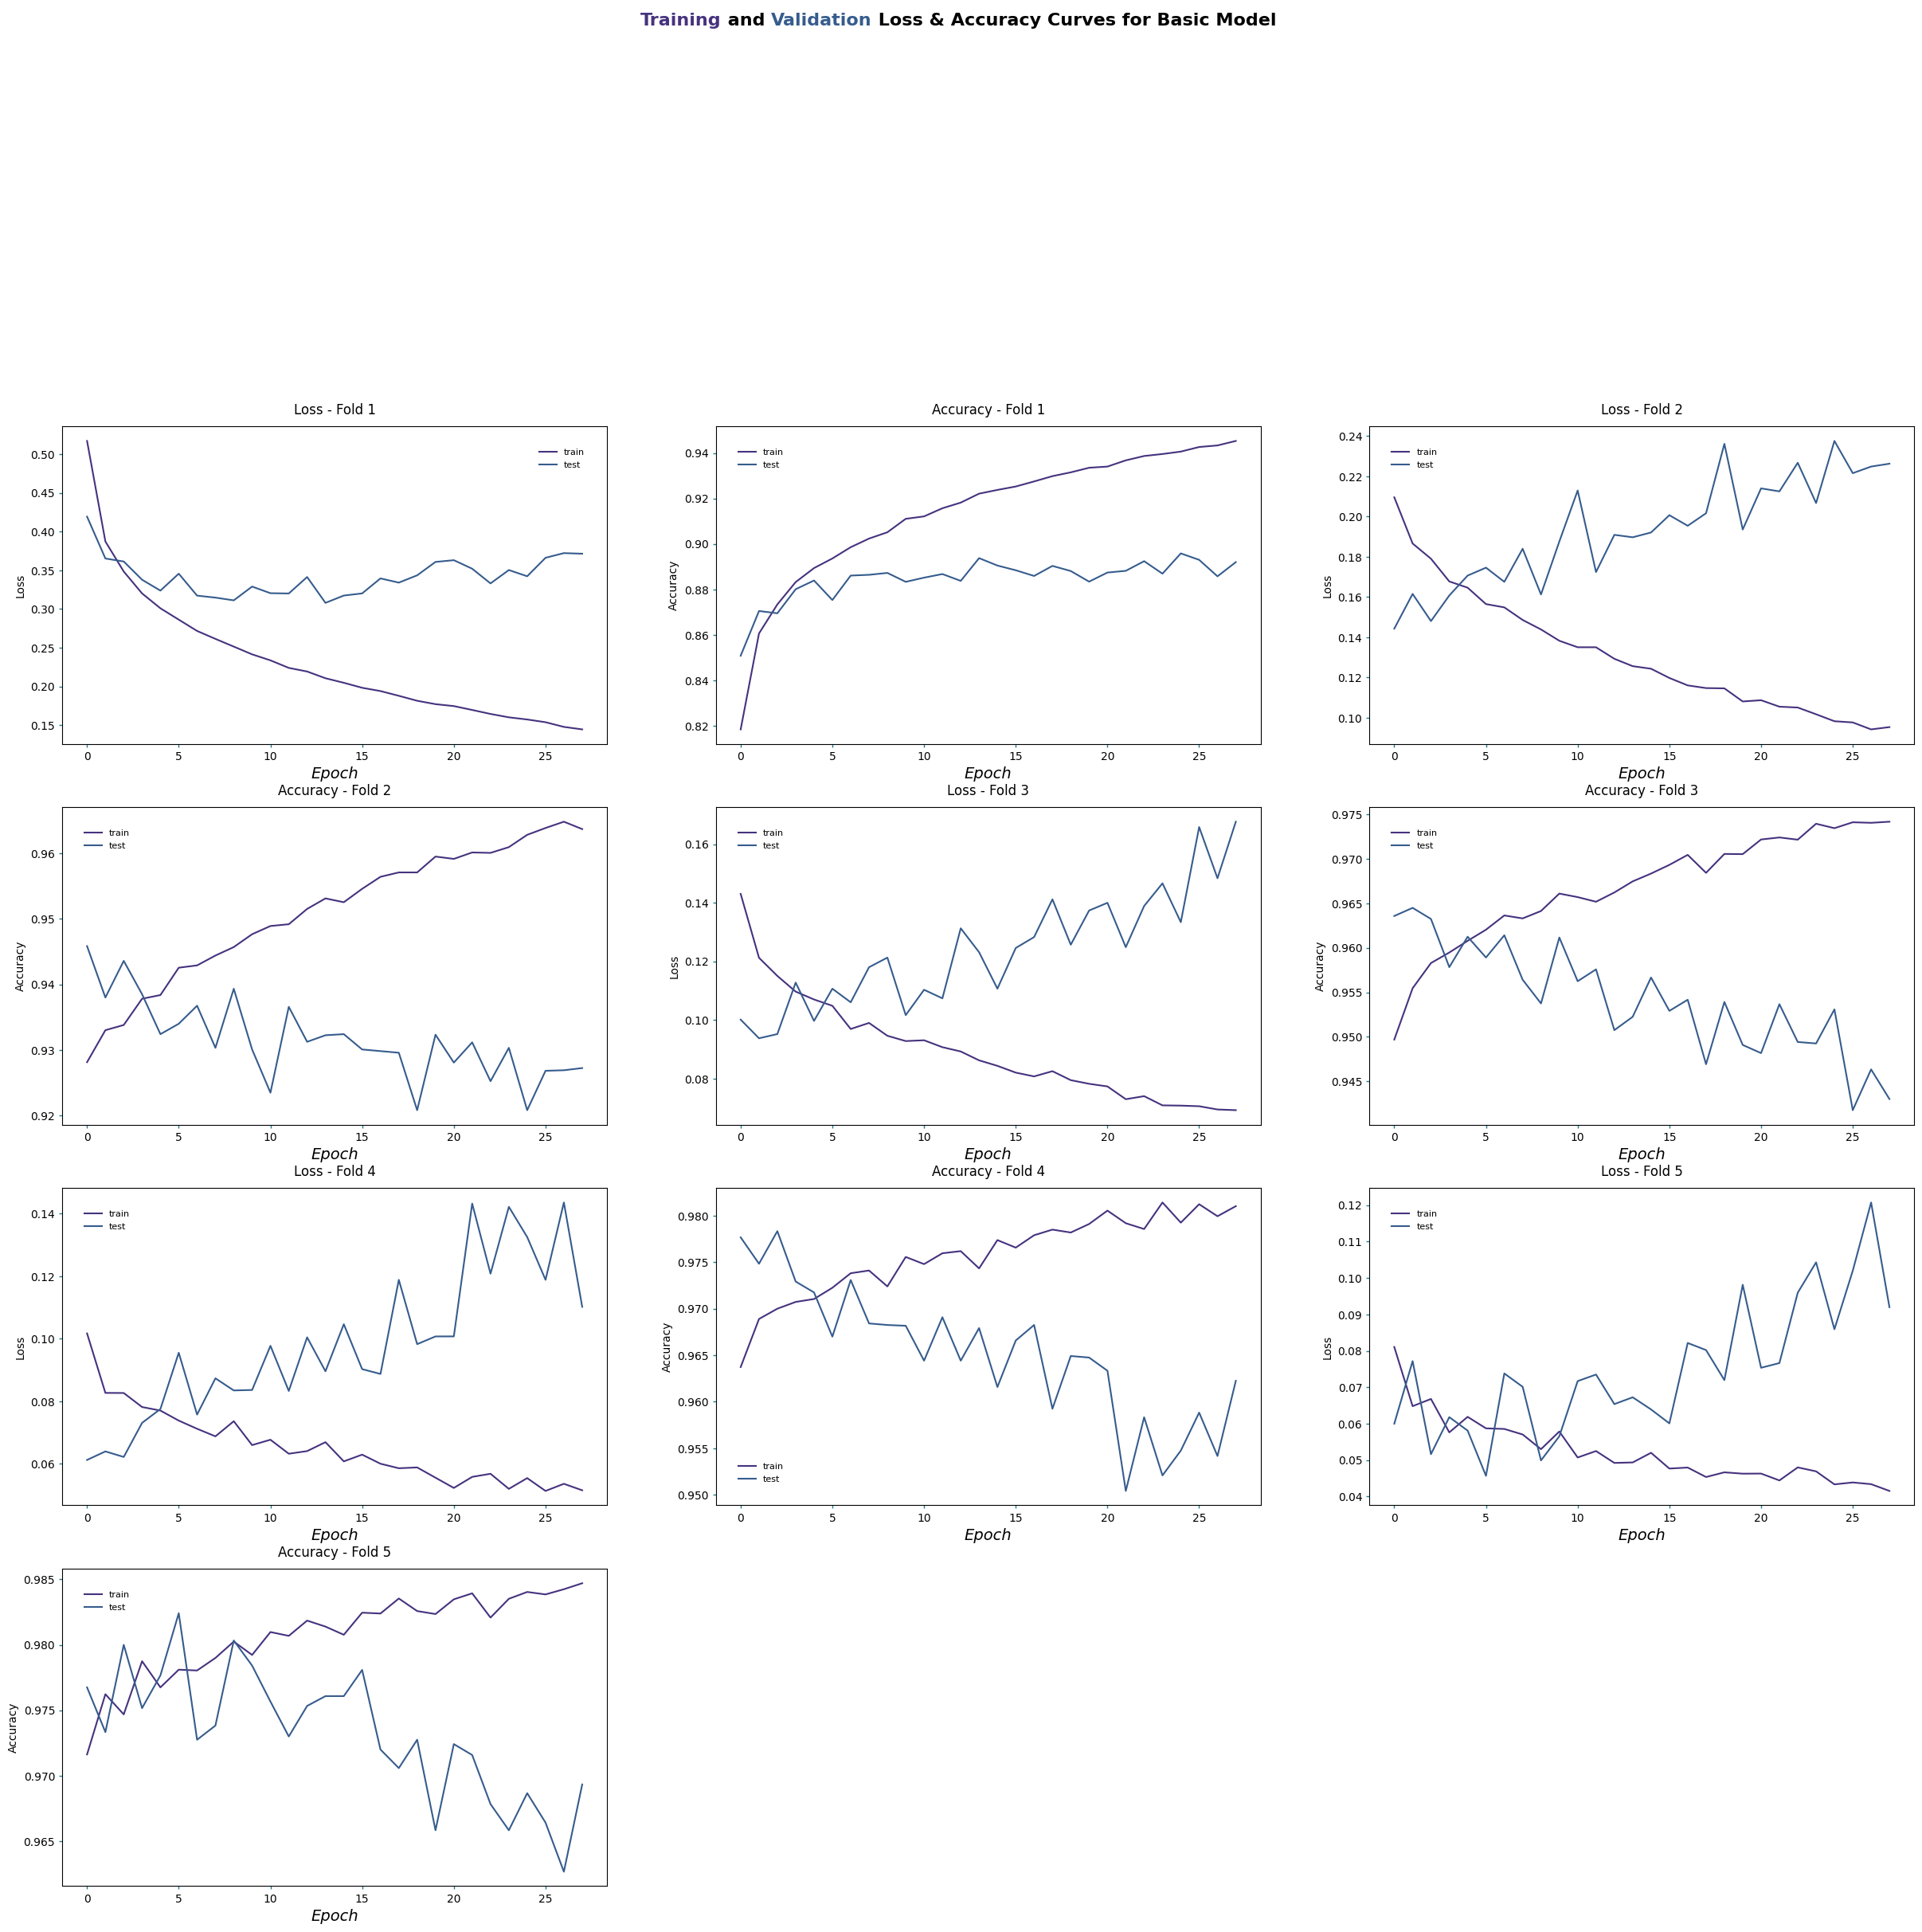

In [ ]:
# --- Loss & Accuracy Curves: Basic Model Settings ---


cols = 3

rows = 5


xlabel = dict(fontsize=14, style='italic', loc='center')


tick_params = dict(length=3, width=1, color=color_line)


legend_style = dict(borderpad=2, frameon=False, fontsize=8)


suptitle = dict(
    x=0.5,
    y=1.05,
    fontsize=16,
    weight='bold',
    ha='center',
    va='center'
)


model_style = dict(
    x=0.5, y=1.03,
    fontsize=12,
    ha='center',
    va='center'
)


suptitle_textprops = [
    {'weight': 'heavy', 'color': colors[0]},  # estilo para "<Training>"
    {'weight': 'heavy', 'color': colors[1]},  # estilo para "<Validation>"
]

# Estilo para resaltar texto del nombre del modelo
highlight_model = [
    {
        'bbox': {                # caja que rodea el texto
            'edgecolor': 'black',
            'facecolor': 'black',
            'pad': 1             # espacio interno
        },
        'color': 'white'         # color del texto
    }
]

# --- Loss Accuracy Curves: Basic Model Plot ---
# Se llama a la función que grafica las curvas de pérdida y precisión
# utilizando las configuraciones anteriores y el historial de los folds.
learning_curves(cols, rows, histories, "Basic Model")


In [ ]:
# Define fashion_list
# Lista con los nombres de las clases del dataset Fashion MNIST.
# El índice de la lista coincide con la etiqueta numérica del modelo.
fashion_list = ['Camiseta/Top',
    'Pantalón',
    'Jersey',
    'Vestido',
    'Abrigo',
    'Sandalia',
    'Camisa',
    'Zapatilla',
    'Bolso',
    'Bota']

# Select a random sample of images from the test set
# Número de imágenes a mostrar (proviene de la variable imgs).

imgs = 10   # o la cantidad que quieras mostrar

num_images = imgs

# Se seleccionan índices aleatorios del set de prueba sin repetición.
sample = np.random.choice(range(len(X_test)), num_images, replace=False)

def plot_image(i):

    plt.imshow(X_test[i], cmap=plt.cm.binary)

    # Obtiene la etiqueta real (one-hot → índice máximo).
    true_label = np.argmax(y_test[i])


    predicted_label = np.argmax(y_pred[i])


    color = 'green' if true_label == predicted_label else 'red'

    # Muestra el nombre de la clase real y la predicha.
    plt.title(f'Actual: {fashion_list[true_label]}\nPredicted: {fashion_list[predicted_label]}',
              color=color)

    # Oculta los ejes para mejor visualización.
    plt.xticks([])
    plt.yticks([])

def plot_value_array(i):
    # Etiqueta real.
    true_label = np.argmax(y_test[i])


    predicted_label = np.argmax(y_pred[i])


    thisplot = plt.bar(range(10), y_pred[i], color=colors[3])

    # Se establece el rango del eje Y (0 a 1 porque son probabilidades).
    plt.ylim([0, 1])

    # Resalta la barra de la clase predicha.
    thisplot[predicted_label].set_color(colors[0])

    # Resalta la barra de la clase real.
    thisplot[true_label].set_color(colors[1])

    # Coloca etiquetas con nombres de clases y las rota 90°.
    plt.xticks(range(10), fashion_list, rotation=90)

    # Define las marcas en el eje Y usando variables predefinidas.
    plt.yticks(y_ticks, y_labels)

    # Aplica estilo a los ticks del gráfico.
    plt.gca().tick_params(**tick_params)

    # Etiquetas de los ejes con estilo.
    plt.xlabel('Classes', **xlabel)
    plt.ylabel('Probability')


    plt.grid(axis='y', linestyle='--', alpha=0.7)


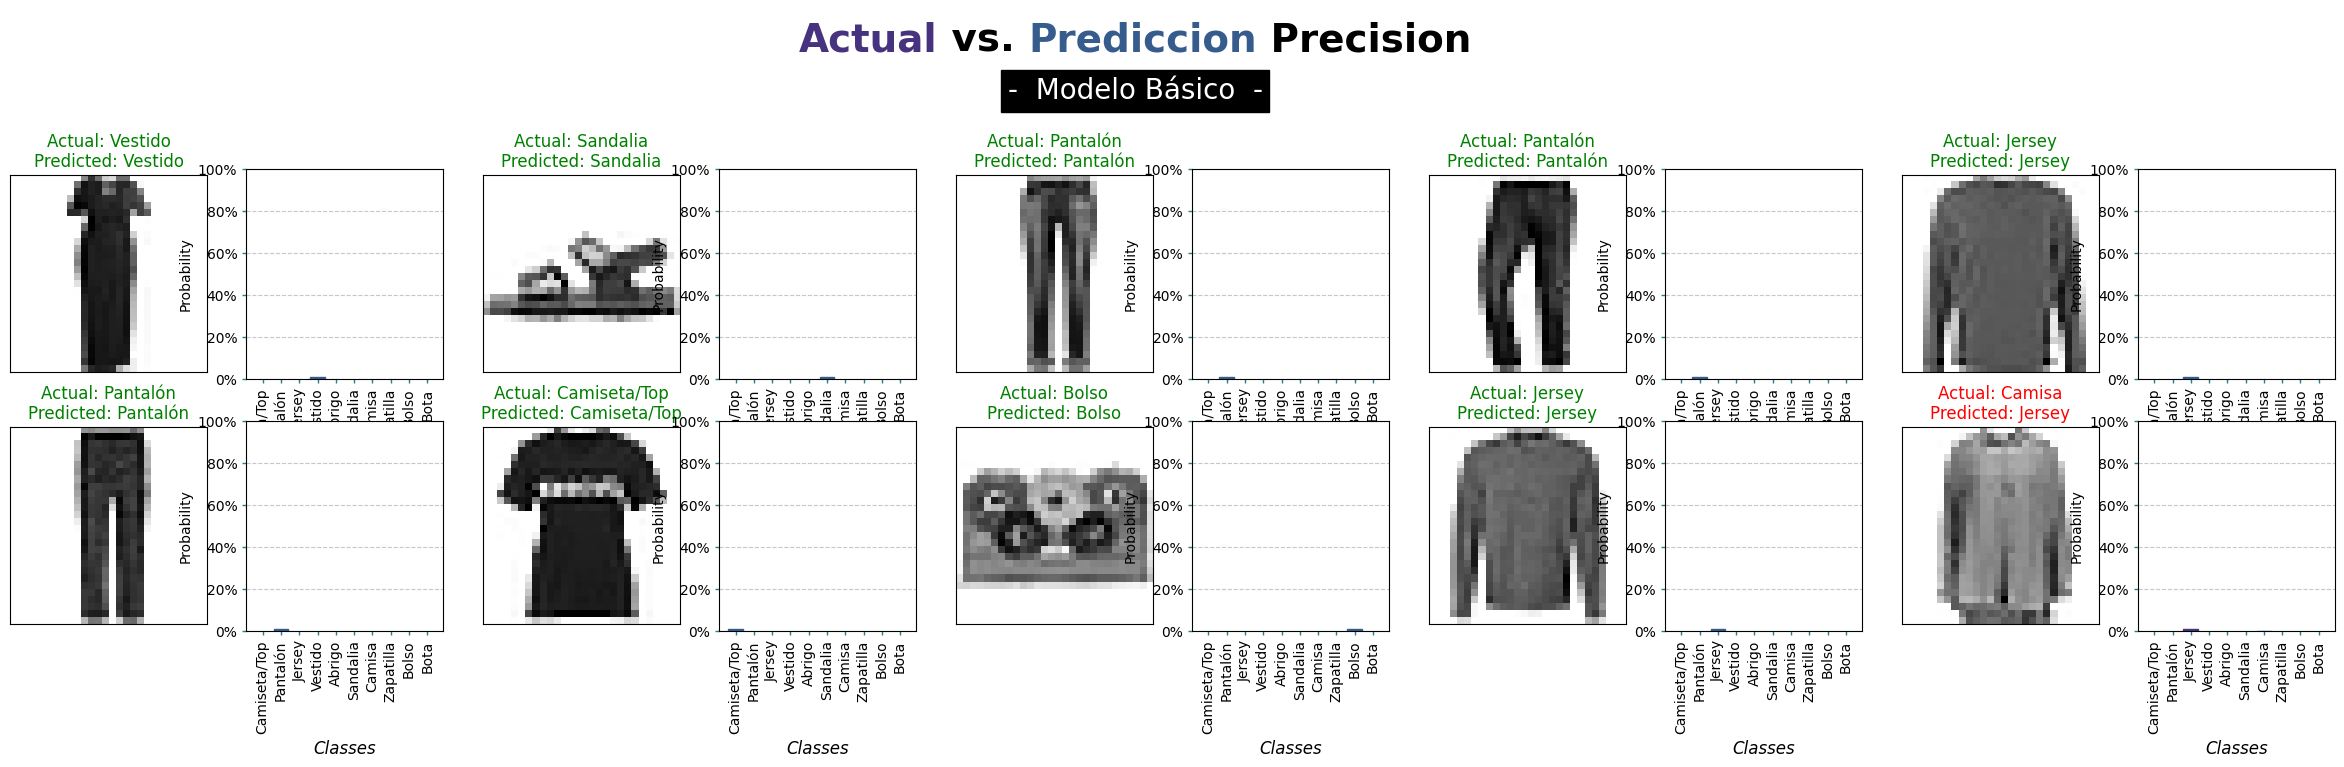

In [ ]:
# --- Basic Model - Sample Image: Settings ---
cols = 5
rows = 2
imgs = rows * cols

# Configuración de los ejes para las barras de probabilidad
y_ticks = list(np.arange(0, 120, 20))               # Valores en el eje Y de 0% a 100% en pasos de 20
y_labels = list(map(str, y_ticks))                  # Convertir valores a string
y_labels = [lbl + "%" for lbl in y_labels]

# Estilos de texto y etiquetas del gráfico
xlabel = dict(fontsize=12, style='italic', loc='center')
suptitle_textprops = dict(x=0.5, y=1.1, fontsize=28, weight='bold',
                          ha='center', va='center')
suptitle_model = dict(x=0.5, y=1.01, fontsize=20,
                      ha='center', va='center')

# Estilos para resaltar texto en el título
highlight_textprops = [{'weight': 'heavy', 'color': colors[0]},
                       {'weight': 'heavy', 'color': colors[1]}]
highlight_model = [{'bbox': {'edgecolor': 'black', 'facecolor': 'black', 'pad': 5},
                    'color': 'white'}]

# --- Basic Model - Showing Sample Images ---
plt.figure(figsize=(6*cols, 3*rows))

# Ciclo para dibujar cada imagen y su barra de predicción
for i in range(imgs):
    num = sample[i]

    # Mostrar imagen real (lado izquierdo de cada par)
    plt.subplot(rows, 2*cols, 2*i+1)
    plot_image(num)

    # Mostrar gráfico de barras con probabilidades (lado derecho)
    plt.subplot(rows, 2*cols, 2*i+2)
    plot_value_array(num)


fig_text(s='\n<Actual> vs. <Prediccion> Precision',
         highlight_textprops=highlight_textprops, **suptitle_textprops)

# Subtítulo que indica que pertenece al modelo básico
fig_text(s='<-  Modelo Básico  ->',
         highlight_textprops=highlight_model, **suptitle_model)



plt.show();


In [ ]:
# Define cmap_list with various colormaps
cmap_list = ['magma', 'viridis', 'plasma', 'inferno', 'cividis', 'Greys', 'Purples',
             'Blues', 'Greens', 'Oranges', 'Reds', 'YlOrBr', 'YlOrRd', 'OrRd',
             'PuBuGn', 'PuBu', 'BuGn', 'GnBu', 'PuRd', 'RdPu', 'BuPu', 'YlGnBu', 'YlGn']
# Lista de colormaps disponibles para personalizar la matriz de confusión o gráficos en general.


def plot_confusion_matrix(y_preds, y_tests, model_name, subtitle):
    cm = confusion_matrix(y_tests, y_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fashion_list)


    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, **conf_mtx_style)


    fig_text(
        s='<Confusion Matrix> for {}'.format(model_name),
        highlight_textprops=highlight_textprops,
        **suptitle
    )


    fig_text(
        s=subtitle,
        highlight_textprops=highlight_model,
        **title
    )


    ax.set_xlabel('Predicted Label', **xylabel)
    ax.set_ylabel('True Label', **xylabel)


    ax.tick_params(axis='x', labelsize=lbl_size, labelrotation=90)
    ax.tick_params(axis='y', labelsize=lbl_size, labelrotation=0)


    plt.tight_layout()
    plt.show()


In [ ]:
# --- Model 1 Classification Report ---
y_preds = y_pred.argmax(axis=1)
y_tests = y_test.argmax(axis=1)
print(clr.start+'.:. Basic Model Classification Report .:.'+clr.end)
print(clr.color+'*'* 42+clr.end)
print(classification_report(y_tests, y_preds, target_names=fashion_list))

.:. Basic Model Classification Report .:.
******************************************
              precision    recall  f1-score   support

Camiseta/Top       0.79      0.86      0.82      1000
    Pantalón       0.99      0.97      0.98      1000
      Jersey       0.79      0.80      0.79      1000
     Vestido       0.88      0.91      0.89      1000
      Abrigo       0.80      0.83      0.82      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.76      0.65      0.70      1000
   Zapatilla       0.94      0.97      0.96      1000
       Bolso       0.98      0.96      0.97      1000
        Bota       0.96      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



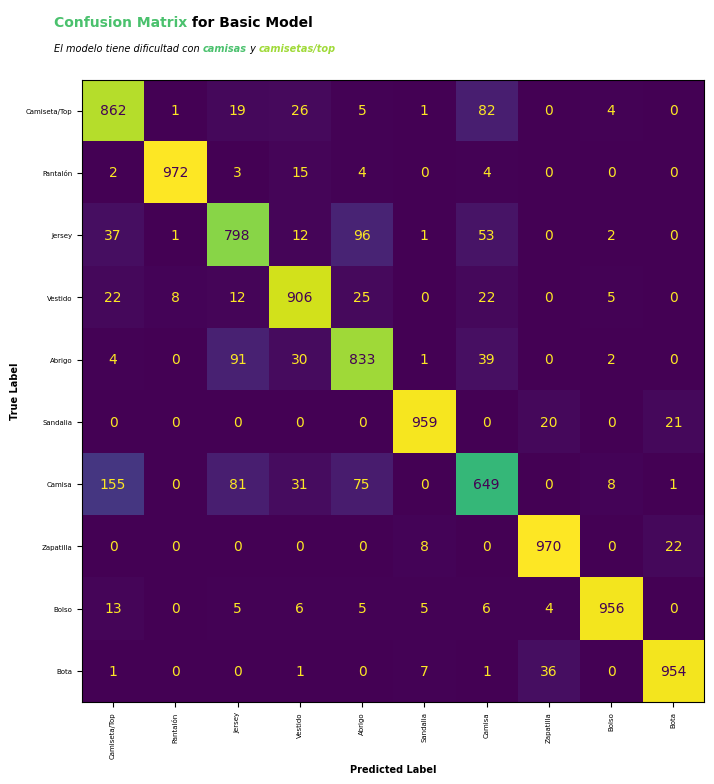

In [ ]:
# --- Basic Model - Conf. Matrix: Settings ---
# Estilo de la matriz de confusión: se define el mapa de colores y se desactiva la barra de color
conf_mtx_style = dict(cmap=cmap_list[1], colorbar=False)

# Configuración del título principal (posición, tamaño de fuente, peso, alineación)
suptitle = dict(x=0.12, y=0.95, fontsize=10, weight='heavy', ha='left', va='bottom')

# Configuración del subtítulo (posición, tamaño de fuente, estilo, peso, alineación)
title = dict(x=0.12, y=0.92, fontsize=7, style='italic', weight='normal', ha='left', va='bottom')

# Configuración de etiquetas de los ejes (tamaño y estilo de fuente)
xylabel = dict(fontsize=7, weight='bold')

# Propiedades para resaltar texto dentro de la matriz (negrita y colores específicos)
# Para el título principal (solo un fragmento <Confusion Matrix>)
highlight_textprops = [
    {'weight': 'bold', 'color': colors[4]}
]

# Para el subtítulo (dos fragmentos <shirts> y <t-shirts/top>)
highlight_model = [
    {'weight': 'bold', 'color': colors[4]},   # estilo para <shirts>
    {'weight': 'bold', 'color': colors[5]}    # estilo para <t-shirts/top>
]

# Tamaño de las etiquetas dentro de la matriz
lbl_size = 5

# --- Basic Model - Conf. Matrix ---
# Subtítulo que describe la dificultad del modelo al clasificar ciertas clases
subtitle = "El modelo tiene dificultad con <camisas> y <camisetas/top>"

# Función que genera y muestra la matriz de confusión con las predicciones y etiquetas reales

plot_confusion_matrix(y_preds, y_tests, "Basic Model", subtitle)




In [ ]:
# --- Model 1 Classification Report ---
# Obtiene las predicciones finales tomando el índice del valor máximo (clase con mayor probabilidad)

y_preds = y_pred.argmax(axis=1)


y_tests = y_test.argmax(axis=1)


print(clr.start+'.:. Reporte del modelo de clasificación .:.'+clr.end)


print(clr.color+'*'* 42+clr.end)


print(classification_report(y_tests, y_preds, target_names=fashion_list))


.:. Reporte del modelo de clasificación .:.
******************************************
              precision    recall  f1-score   support

Camiseta/Top       0.79      0.86      0.82      1000
    Pantalón       0.99      0.97      0.98      1000
      Jersey       0.79      0.80      0.79      1000
     Vestido       0.88      0.91      0.89      1000
      Abrigo       0.80      0.83      0.82      1000
    Sandalia       0.98      0.96      0.97      1000
      Camisa       0.76      0.65      0.70      1000
   Zapatilla       0.94      0.97      0.96      1000
       Bolso       0.98      0.96      0.97      1000
        Bota       0.96      0.95      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:

cmap_list = ['magma', 'viridis', 'plasma', 'inferno', 'cividis', 'Greys', 'Purples',
             'Blues', 'Greens', 'Oranges', 'Reds', 'YlOrBr', 'YlOrRd', 'OrRd',
             'PuBuGn', 'PuBu', 'BuGn', 'GnBu', 'PuRd', 'RdPu', 'BuPu', 'YlGnBu', 'YlGn']


def plot_confusion_matrix(y_preds, y_tests, model_name, subtitle):

    cm = confusion_matrix(y_tests, y_preds)


    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fashion_list)


    fig, ax = plt.subplots(figsize=(8, 8))


    disp.plot(ax=ax, **conf_mtx_style)


    fig_text(
        s='<Confusion Matrix> for {}'.format(model_name),
        highlight_textprops=highlight_textprops,
        **suptitle
    )


    fig_text(
        s=subtitle,
        highlight_textprops=highlight_model,
        **title
    )

    # Etiquetas de los ejes con estilo personalizado
    ax.set_xlabel('Predicted Label', **xylabel)
    ax.set_ylabel('True Label', **xylabel)


    ax.tick_params(axis='x', labelsize=lbl_size, labelrotation=90)
    ax.tick_params(axis='y', labelsize=lbl_size, labelrotation=0)


    plt.tight_layout()


    plt.show()



El segundo modelo será una versión ampliada y optimizada, diseñada para superar las limitaciones del modelo base.

Incluye:

### 1. Arquitectura más profunda y con más filtros

Agregar más capas convolucionales y aumentar los filtros permite que el modelo aprenda:

* patrones más complejos
* detalles más finos
* texturas avanzadas de las telas
* formas similares que el modelo 1 no lograba distinguir

Lo que se espera mejorar:

* El modelo 1 puede confundir *shirts* con *t-shirts*
* El modelo 2 puede captar diferencias sutiles como:

  * cuello
  * largo de la manga
  * densidad de textura

### 2. Regularización adicional

Además del Dropout, la arquitectura mejorada puede incluir:

* más capas de dropout
* regularización L2
* mayor control de pesos

Esto:

* reduce el riesgo de sobreajuste al ser un modelo más grande
* mejora la estabilidad durante el entrenamiento


### 3. Batch Normalization

BatchNorm ayuda a:

* estabilizar la distribución interna de activaciones
* acelerar el entrenamiento
* permitir tasas de aprendizaje más altas
* reducir sensibilidad a inicializaciones


Tratar de caer en:

* vanishing gradients
* oscilaciones
* entrenamientos lentos


In [ ]:
# --- Building Experiment Model 1 ---
# Se construye un modelo secuencial de Keras, llamado 'model_2', que representa
# una arquitectura CNN mejorada respecto al modelo básico.
model_2 = tf.keras.Sequential([

    # Primera capa convolucional:
    # - 32 filtros
    # - Kernels de tamaño 3x3
    # - Activación ReLU para introducir no linealidad
    # - Inicializador He (he_uniform) para mejorar el rendimiento con ReLU
    # - input_shape define imágenes de 28x28 en escala de grises (1 canal)
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu',
                           kernel_initializer='he_uniform',
                           input_shape=(28, 28, 1)),

    # Capa de MaxPooling:
    # Reduce la dimensionalidad tomando el valor máximo en ventanas 2x2.
    # Ayuda a extraer características más robustas y disminuir parámetros.
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten convierte la salida 2D de la CNN en un vector 1D
    # para alimentar a las capas densas.
    tf.keras.layers.Flatten(),

    # Capa densa oculta:
    # - 100 neuronas
    # - ReLU como activación
    # - Inicializador He para mejorar el aprendizaje
    tf.keras.layers.Dense(100, activation='relu',
                          kernel_initializer='he_uniform'),

    # Capa de salida:
    # - 10 neuronas (10 clases del dataset Fashion-MNIST)
    # - Softmax para obtener probabilidades por clase
    tf.keras.layers.Dense(10, activation='softmax')
])

# --- Experiment Model 1 Summary ---
# Imprime un título con formato de color
print(clr.start+'.:. Experiment Model 1 Summary .:.'+clr.end)

# Se imprime una línea decorativa para el encabezado
print(clr.color+'*'* 65+clr.end)

# Muestra el resumen estructural del modelo:
# capas, tamaños de salida y cantidad de parámetros entrenables.
model_2.summary()


.:. Experiment Model 1 Summary .:.
*****************************************************************


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       540,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,230 (2.07 MB)

 Trainable params: 542,230 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Experiment Model 1 - Parameters ---
# Se compila el modelo 'model_2' usando:
# - Optimizador Adam: buen rendimiento general y ajuste automático de tasas de aprendizaje.
# - Pérdida categorical_crossentropy: adecuada para clasificación multiclase con softmax.
# - Métrica accuracy: para monitorear el porcentaje de aciertos.
model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- K-fold CV Parameters ---
# Se configura una validación cruzada K-fold con:
# - n_splits=5: dividir los datos en 5 grupos (4 entrenan, 1 valida en cada iteración)
# - shuffle=True: mezcla los datos antes de dividirlos
# - random_state=42: garantiza reproducibilidad del shuffle
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Variables to Save the Results ---
# Se inicializan listas vacías donde se guardarán:
# - histories: curvas de pérdida y precisión de cada pliegue
# - scores: las puntuaciones finales en cada fold
# - losses: pérdidas registradas por cada fold
histories, scores, losses = list(), list(), list()

# --- Fitting Experiment Model 1 using K-fold ---
# Ejecuta el entrenamiento usando validación cruzada K-fold.
# La función fitting_model:
# - entrena el modelo en varios folds
# - guarda el historial de métricas
# - genera las puntuaciones por fold
# - devuelve históricas, pérdidas y scores actualizados
# "35" puede ser el número de épocas o un seed según la implementación.
history, score, losses, scores, histories = fitting_model(model_2, "Experiment Model 1", 35)

# --- Create Prediction for Experiment Model 1 ---
# Se generan predicciones del modelo ya entrenado.
# create_prediction:
# - usa model_2 para predecir las clases del set de test
# - retorna un arreglo de predicciones procesado (probabilidades o clases)
# "45" puede ser un ID visual/número decorativo según el formato de impresión.
y_pred = create_prediction(model_2, "Experiment Model 1", 45)

# --- Evaluate Experiment Model 1 on Test Data ---
# Se evalúa el modelo final sobre el dataset de prueba real.
# evaluate_model:
# - retorna test_loss y test_acc del modelo ya entrenado
# - imprime resultados con un formato personalizado
# "49" nuevamente es un número usado dentro del reporte personalizado.
test_loss, test_acc = evaluate_model(model_2,  "Experiment Model 1", 49)



******************************
>> Fold 1 - Experiment Model 1 <<
******************************
	.:. Val Loss: 0.6922
	.:. Val Accuracy: 0.9076

******************************
>> Fold 2 - Experiment Model 1 <<
******************************
	.:. Val Loss: 0.1632
	.:. Val Accuracy: 0.9661

******************************
>> Fold 3 - Experiment Model 1 <<
******************************
	.:. Val Loss: 0.0727
	.:. Val Accuracy: 0.9824

******************************
>> Fold 4 - Experiment Model 1 <<
******************************
	.:. Val Loss: 0.0411
	.:. Val Accuracy: 0.9894

******************************
>> Fold 5 - Experiment Model 1 <<
******************************
	.:. Val Loss: 0.0117
	.:. Val Accuracy: 0.9970

******************************
>> Promedio de métricas de Experiment Model 1 <<
******************************
	.:. Pérdida Promedio (Val Loss): 0.1962
	.:. Precisión Promedio (Val Accuracy): 0.9685

.:. Creando Predicciones para Experiment Model 1 .:.
*********************

In [ ]:
# --- Evaluate Accuracy and Loss Score of Experiment Model 1 ---
# Se imprime un encabezado estilizado usando códigos de color definidos en 'clr'.
# Indica que se van a mostrar los resultados de precisión (accuracy) y pérdida (loss)
# del modelo "Experiment Model 1" evaluado en el conjunto de prueba.
print(clr.start+'.:. Evaluate Accuracy and Loss Score of Experiment Model 1 .:.'+clr.end)
print(clr.color+'*'* 63+clr.end)

# Muestra la precisión del modelo multiplicada por 100 para expresarla en porcentaje,
# formateada a 2 decimales. 'test_acc' proviene de evaluate_model().
print('>> Test Accuracy: '+clr.start+f'{test_acc*100:.2f}%'+clr.end)

# Muestra la pérdida (loss) obtenida por el modelo en el test set,
# formateada a 3 decimales.
print('>> Test Loss: '+clr.start+f'{test_loss:.3f}'+clr.end)

# --- Experiment Model 1 Performance Summary ---
# Se calculan estadísticas usando los valores obtenidos en la validación cruzada (K-fold):
# - mean_scores: promedio de accuracy en todos los folds
# - std_scores: desviación estándar del accuracy entre los folds
# - len_scores: número total de folds (normalmente 5)
# - mean_loss: pérdida promedio entre los folds
mean_scores = np.mean(scores)
std_scores = np.std(scores)
len_scores = len(scores)
mean_loss = np.mean(losses)

# Se imprime otro encabezado decorado donde se mostrará el resumen del desempeño promedio.
print('\n'+clr.start+'.:. Experiment Model 1 Avg. Performance Summary .:.'+clr.end)
print(clr.color+'*'* 52+clr.end)

# Muestra el accuracy promedio multiplicado por 100 para expresarlo como porcentaje.
print('>>> Avg. Accuracy: '+clr.start+f'{mean_scores*100:.2f}%'+clr.end)

# Muestra la desviación estándar para entender qué tan consistente fue el modelo entre folds.
print('>>> Standard Deviation: '+clr.start+f'{std_scores:.3f}'+clr.end)

# Muestra la pérdida promedio entre todos los folds.
print('>>> Avg. Loss: '+clr.start+f'{mean_loss:.3f}'+clr.end)

# Muestra cuántos folds se utilizaron en el K-fold CV.
print('>>> N Folds: '+clr.start+f'{len_scores}'+clr.end)


.:. Evaluate Accuracy and Loss Score of Experiment Model 1 .:.
***************************************************************
>> Test Accuracy: 90.45%
>> Test Loss: 1.491

.:. Experiment Model 1 Avg. Performance Summary .:.
****************************************************
>>> Avg. Accuracy: 96.85%
>>> Standard Deviation: 0.032
>>> Avg. Loss: 0.196
>>> N Folds: 5


/tmp/ipython-input-845900702.py:53: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


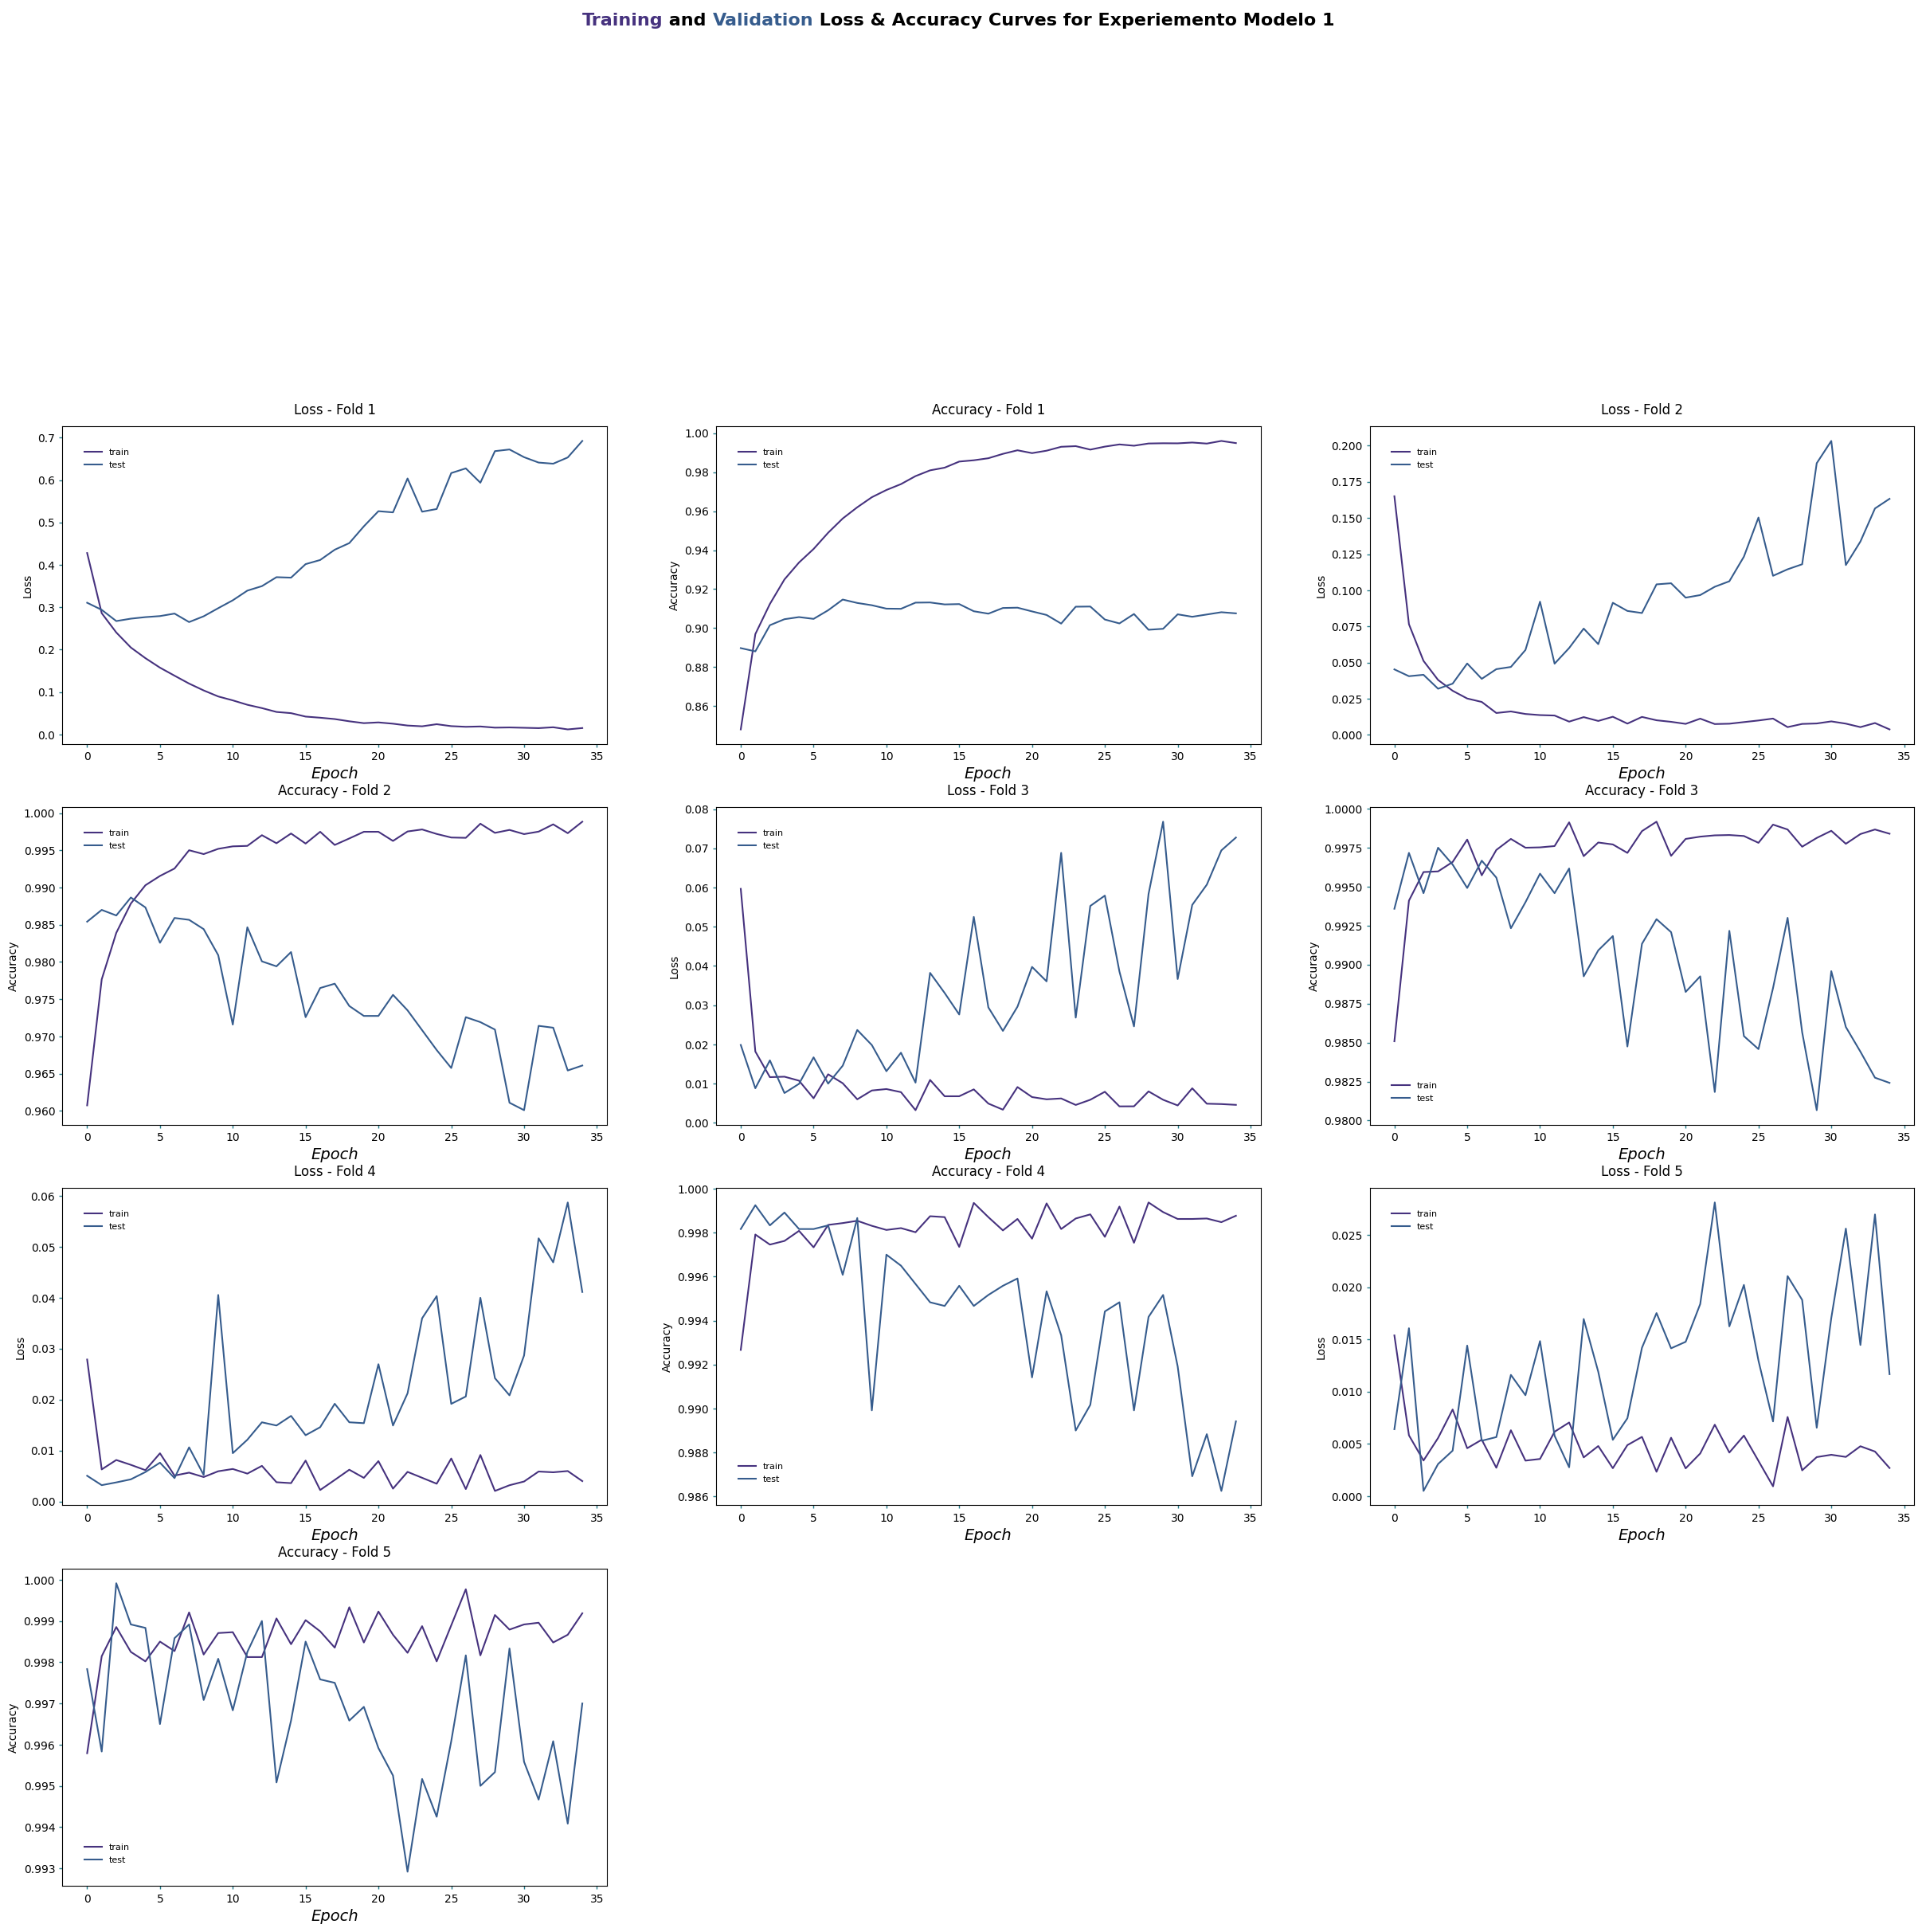

In [ ]:
# --- Loss & Accuracy Curves: Experiment Model 1 Settings ---

cols = 3
rows = 5


xlabel = dict(fontsize=14, style='italic', loc='center')


tick_params = dict(length=3, width=1, color=color_line)


legend_style = dict(borderpad=2, frameon=False, fontsize=8)


suptitle = dict(x=0.5, y=1.05, fontsize=16, weight='bold', ha='center', va='center')


model_style = dict(x=0.5, y=1.03, fontsize=12, ha='center', va='center')


suptitle_textprops = [{'weight': 'heavy', 'color': colors[0]},
                      {'weight': 'heavy', 'color': colors[1]},
                      ]


highlight_model =[{'bbox': {'edgecolor': 'black',
                            'facecolor': 'black',
                            'pad': 1},
                   'color': 'white'}]


learning_curves(cols, rows, histories, "Experiemento Modelo 1")


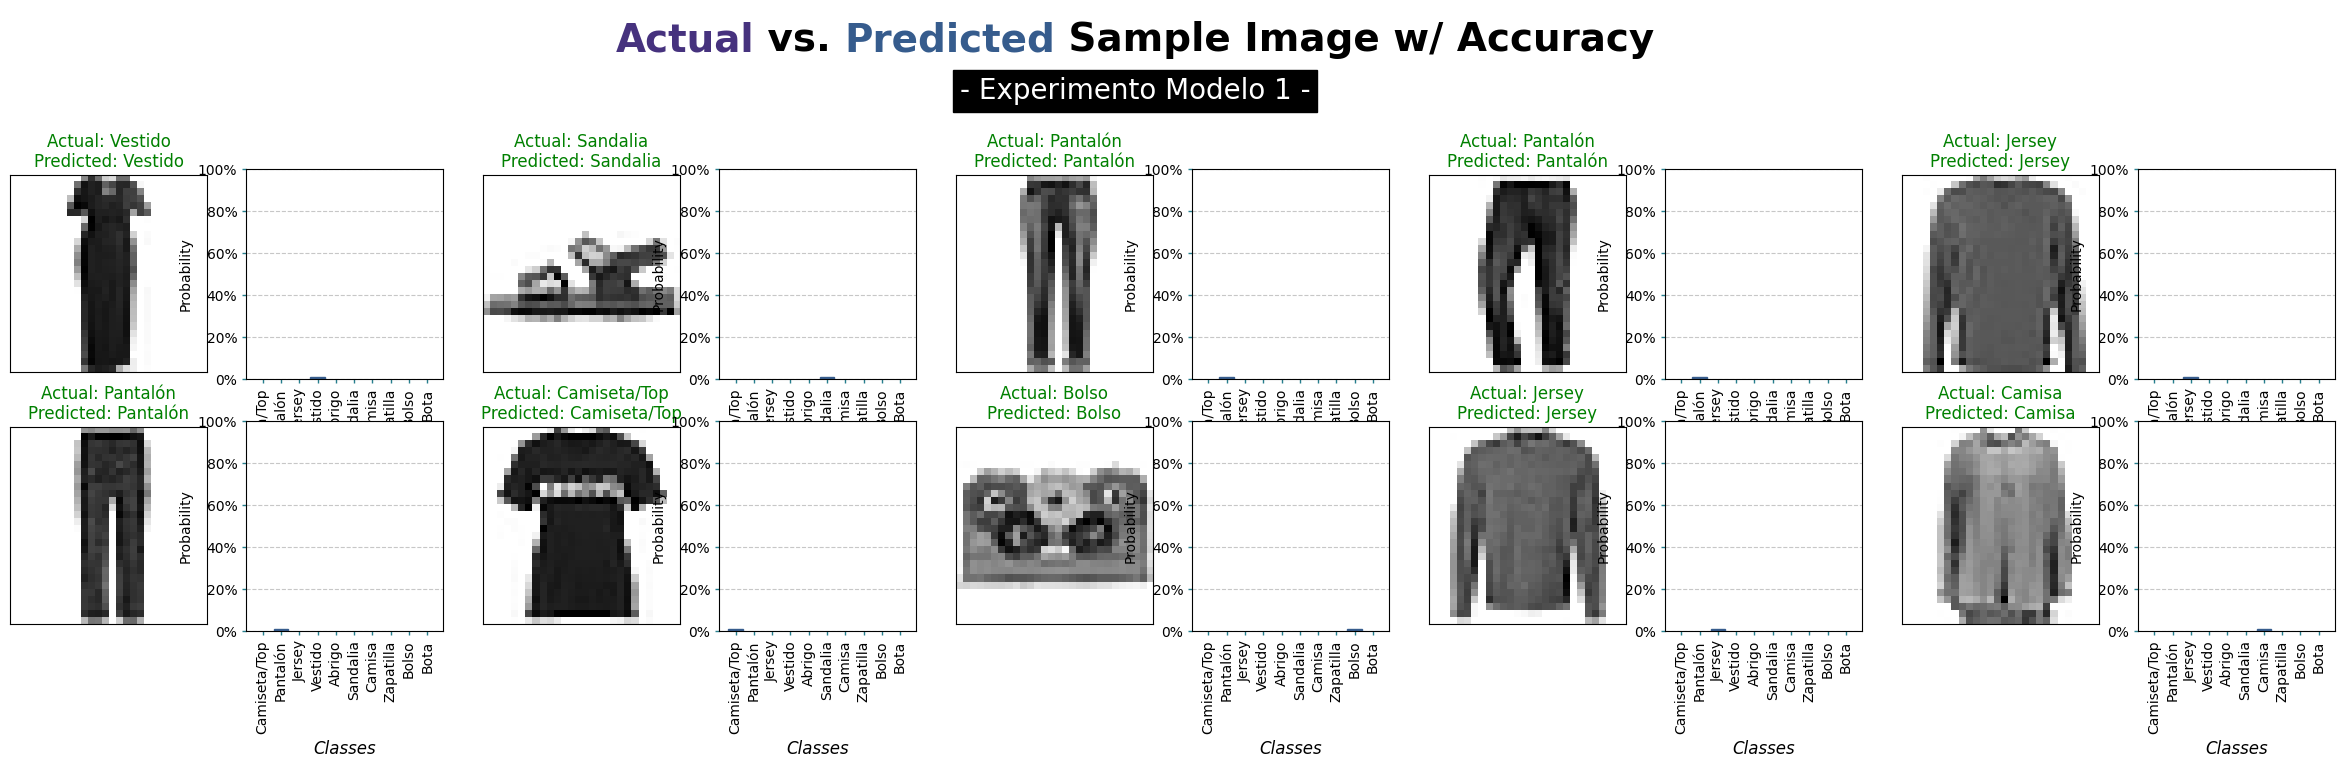

In [ ]:
cols = 5
rows = 2


imgs = rows * cols


y_ticks = list(np.arange(0, 120, 20))


y_labels = list(map(str, y_ticks))


y_labels = [lbl + "%" for lbl in y_labels]


xlabel = dict(fontsize=12, style='italic', loc='center')


suptitle_textprops = dict(x=0.5, y=1.1, fontsize=28, weight='bold',
                          ha='center', va='center')


suptitle_model = dict(x=0.5, y=1.01, fontsize=20,
                      ha='center', va='center')


highlight_textprops = [
    {'weight': 'heavy', 'color': colors[0]},
    {'weight': 'heavy', 'color': colors[1]}
]


highlight_model = [
    {'bbox': {'edgecolor': 'black', 'facecolor': 'black', 'pad': 5},
     'color': 'white'}
]


plt.figure(figsize=(6*cols, 3*rows))

# Se itera sobre todas las imágenes seleccionadas en 'sample'.
for i in range(imgs):
    # 'num' guarda el índice de la imagen en el dataset.
    num = sample[i]


    plt.subplot(rows, 2*cols, 2*i + 1)
    plot_image(num)  # Función personalizada: dibuja la imagen real + etiqueta esperada.

    # Segundo subplot: muestra el gráfico de probabilidades.
    plt.subplot(rows, 2*cols, 2*i + 2)
    plot_value_array(num)  # Función personalizada: barras de probabilidad por clase.

# Título principal usando fig_text (encima de la figura).
fig_text(
    s='\n<Actual> vs. <Predicted> Sample Image w/ Accuracy',
    highlight_textprops=highlight_textprops,
    **suptitle_textprops
)


fig_text(
    s='<- Experimento Modelo 1 ->',
    highlight_textprops=highlight_model,
    **suptitle_model
)


plt.show()


In [ ]:
# --- Experiment Model 1 Classification Report ---


y_preds = y_pred.argmax(axis=1)


y_tests = y_test.argmax(axis=1)


print(clr.start+'.:. Experimento Modelo 1 Reporte de clasificacion .:.'+clr.end)


print(clr.color+'*'* 49+clr.end)


print(classification_report(y_tests, y_preds, target_names=fashion_list))


.:. Experimento Modelo 1 Reporte de clasificacion .:.
*************************************************
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.85      0.84      1000
    Pantalón       0.99      0.97      0.98      1000
      Jersey       0.85      0.84      0.85      1000
     Vestido       0.89      0.92      0.90      1000
      Abrigo       0.85      0.85      0.85      1000
    Sandalia       0.97      0.98      0.98      1000
      Camisa       0.74      0.74      0.74      1000
   Zapatilla       0.96      0.96      0.96      1000
       Bolso       0.99      0.97      0.98      1000
        Bota       0.96      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



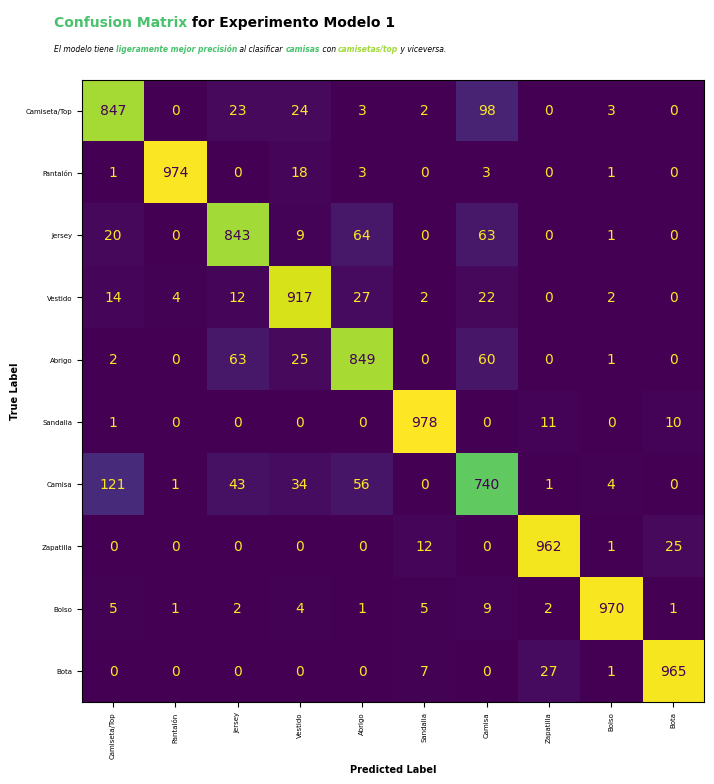

In [ ]:
# --- Experiment Model 1 - Conf. Matrix: Settings ---


conf_mtx_style = dict(cmap=cmap_list[1], colorbar=False)


suptitle = dict(x=0.12, y=0.95, fontsize=10, weight='heavy', ha='left', va='bottom')


title = dict(x=0.12, y=0.92, fontsize=5.5, style='italic', weight='normal', ha='left', va='bottom')


xylabel = dict(fontsize=7, weight='bold')


highlight_textprops = [
    {'weight': 'bold', 'color': colors[4]}
]

# Para el subtítulo (dos fragmentos <shirts> y <t-shirts/top>)
highlight_model = [
    {'weight': 'bold', 'color': colors[4]},
    {'weight': 'bold', 'color': colors[4]},   # estilo para <shirts>
    {'weight': 'bold', 'color': colors[5]}    # estilo para <t-shirts/top>
]

# highlight_textprops = [
#     {'weight': 'bold'},
#     {'weight': 'bold', 'color': colors[4]},
#     {'weight': 'bold', 'color': colors[5]},

#]

lbl_size = 5


# --- Experiment Model 1 - Conf. Matrix ---


subtitle = "El modelo tiene <ligeramente mejor precisión> al clasificar <camisas> con <camisetas/top> y viceversa."


plot_confusion_matrix(y_preds, y_tests, "Experimento Modelo 1", subtitle)


In [ ]:
# --- Building Experiment Model 2 ---
# Definición del tercer modelo (Experiment Model 2) usando una arquitectura CNN más profunda.
model_3 = tf.keras.Sequential([
    # Primera capa convolucional con 32 filtros de tamaño 3x3 y activación ReLU.
    # Se define la forma de entrada de 28x28 en escala de grises.
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    # Primera capa de MaxPooling para reducir dimensión espacial.
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Segunda capa convolucional con 64 filtros, también 3x3 y activación ReLU.
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    # Segunda capa de MaxPooling que reduce nuevamente el tamaño de la imagen.
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Aplana las características extraídas para pasar a capas densas.
    tf.keras.layers.Flatten(),

    # Capa densa con 64 neuronas y activación ReLU para aprendizaje no lineal.
    tf.keras.layers.Dense(64, activation='relu'),

    # Capa de salida con 10 neuronas (una por clase), activación softmax.
    tf.keras.layers.Dense(10, activation='softmax')
])

# --- Experiment Model 2 Summary ---
# Imprime un título formateado para el resumen del modelo.
print(clr.start+'.:. Experiment Model 2 Summary .:.'+clr.end)

# Separador visual.
print(clr.color+'*'* 65+clr.end)

# Muestra el resumen de arquitectura del modelo.
model_3.summary()


.:. Experiment Model 2 Summary .:.
*****************************************************************


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Experiment Model 2 - Parameters ---
# Se compila el modelo especificando:
# - Optimizador Adam (ajuste automático del learning rate)
# - Función de pérdida: categorical_crossentropy (para clasificación multiclase)
# - Métrica principal: accuracy
model_3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# --- K-fold CV Parameters ---
# Se define un esquema de validación cruzada K-Fold con:
# - 5 divisiones (n_splits=5)
# - Barajado previo de los datos (shuffle=True)
# - Semilla fija para reproducibilidad (random_state=42)
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Variables to Save the Results ---
# Listas vacías donde se almacenarán:
# - histories: historial de entrenamiento para cada fold
# - scores: precisión obtenida en cada fold
# - losses: pérdida obtenida en cada fold
histories, scores, losses = list(), list(), list()

# --- Fitting Experiment Model 2 using K-fold ---
# Entrena el modelo usando la función personalizada "fitting_model"
# Parámetros:
# - model_3: el modelo de la arquitectura CNN 2
# - "Experiment Model 2": nombre identificador
# - 35: límite de número de épocas o iteraciones internas definido en tu función
# Retorna:
# - history: historial del último fold
# - score: precisión del último fold
# - losses, scores, histories: listas completas actualizadas
history, score, losses, scores, histories = fitting_model(model_3, "Experiment Model 2", 35)

# --- Create Prediction for Experiment Model 2 ---
# Genera predicciones usando la función personalizada "create_prediction"
# - model_3: modelo ya entrenado
# - "Experiment Model 2": nombre identificador
# - 45: índice o referencia interna usada por tu función para control/identificación
y_pred = create_prediction(model_3, "Experiment Model 2", 45)

# --- Evaluate Experiment Model 2 on Test Data ---
# Evalúa el modelo con los datos de prueba usando la función evaluadora personalizada.
# Retorna:
# - test_loss: pérdida en test
# - test_acc: precisión en test
test_loss, test_acc = evaluate_model(model_3,  "Experiment Model 2", 49)



******************************
>> Fold 1 - Experiment Model 2 <<
******************************
	.:. Val Loss: 0.6472
	.:. Val Accuracy: 0.9058

******************************
>> Fold 2 - Experiment Model 2 <<
******************************
	.:. Val Loss: 0.2788
	.:. Val Accuracy: 0.9504

******************************
>> Fold 3 - Experiment Model 2 <<
******************************
	.:. Val Loss: 0.1417
	.:. Val Accuracy: 0.9699

******************************
>> Fold 4 - Experiment Model 2 <<
******************************
	.:. Val Loss: 0.0829
	.:. Val Accuracy: 0.9806

******************************
>> Fold 5 - Experiment Model 2 <<
******************************
	.:. Val Loss: 0.0531
	.:. Val Accuracy: 0.9890

******************************
>> Promedio de métricas de Experiment Model 2 <<
******************************
	.:. Pérdida Promedio (Val Loss): 0.2407
	.:. Precisión Promedio (Val Accuracy): 0.9591

.:. Creando Predicciones para Experiment Model 2 .:.
*********************

In [ ]:
# --- Evaluate Accuracy and Loss Score of Experiment Model 2 ---
# Encabezado con formato de colores para indicar que se va a evaluar la precisión y la pérdida del modelo 2
print(clr.start+'.:. Evaluate Accuracy and Loss Score of Experiment Model 2 .:.'+clr.end)
print(clr.color+'*'* 63+clr.end)

# Muestra la precisión (accuracy) sobre los datos de prueba convertida a porcentaje.
print('>> Test Accuracy: '+clr.start+f'{test_acc*100:.2f}%'+clr.end)

# Muestra la pérdida (loss) sobre los datos de prueba con tres decimales.
print('>> Test Loss: '+clr.start+f'{test_loss:.3f}'+clr.end)

# --- Experiment Model 2 Performance Summary ---
# Calcula el promedio de las puntuaciones obtenidas en los 5 folds.
mean_scores = np.mean(scores)

# Calcula la desviación estándar para ver qué tanto varían los resultados entre los folds.
std_scores = np.std(scores)

# Guarda cuántos folds fueron utilizados (normalmente 5).
len_scores = len(scores)

# Calcula el promedio general de pérdidas entre los folds.
mean_loss = np.mean(losses)

# Se imprimen los encabezados del resumen de rendimiento (K-fold cross validation).
print('\n'+clr.start+'.:. Experiment Model 2 Avg. Performance Summary .:.'+clr.end)
print(clr.color+'*'* 52+clr.end)

# Muestra la precisión promedio del modelo en K-fold (en porcentaje).
print('>>> Avg. Accuracy: '+clr.start+f'{mean_scores*100:.2f}%'+clr.end)

# Indica qué tanto varía el desempeño entre folds (mientras menor, más estable es el modelo).
print('>>> Standard Deviation: '+clr.start+f'{std_scores:.3f}'+clr.end)

# Muestra la pérdida promedio entre los folds.
print('>>> Avg. Loss: '+clr.start+f'{mean_loss:.3f}'+clr.end)

# Muestra el número total de folds utilizados.
print('>>> N Folds: '+clr.start+f'{len_scores}'+clr.end)


/tmp/ipython-input-845900702.py:53: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


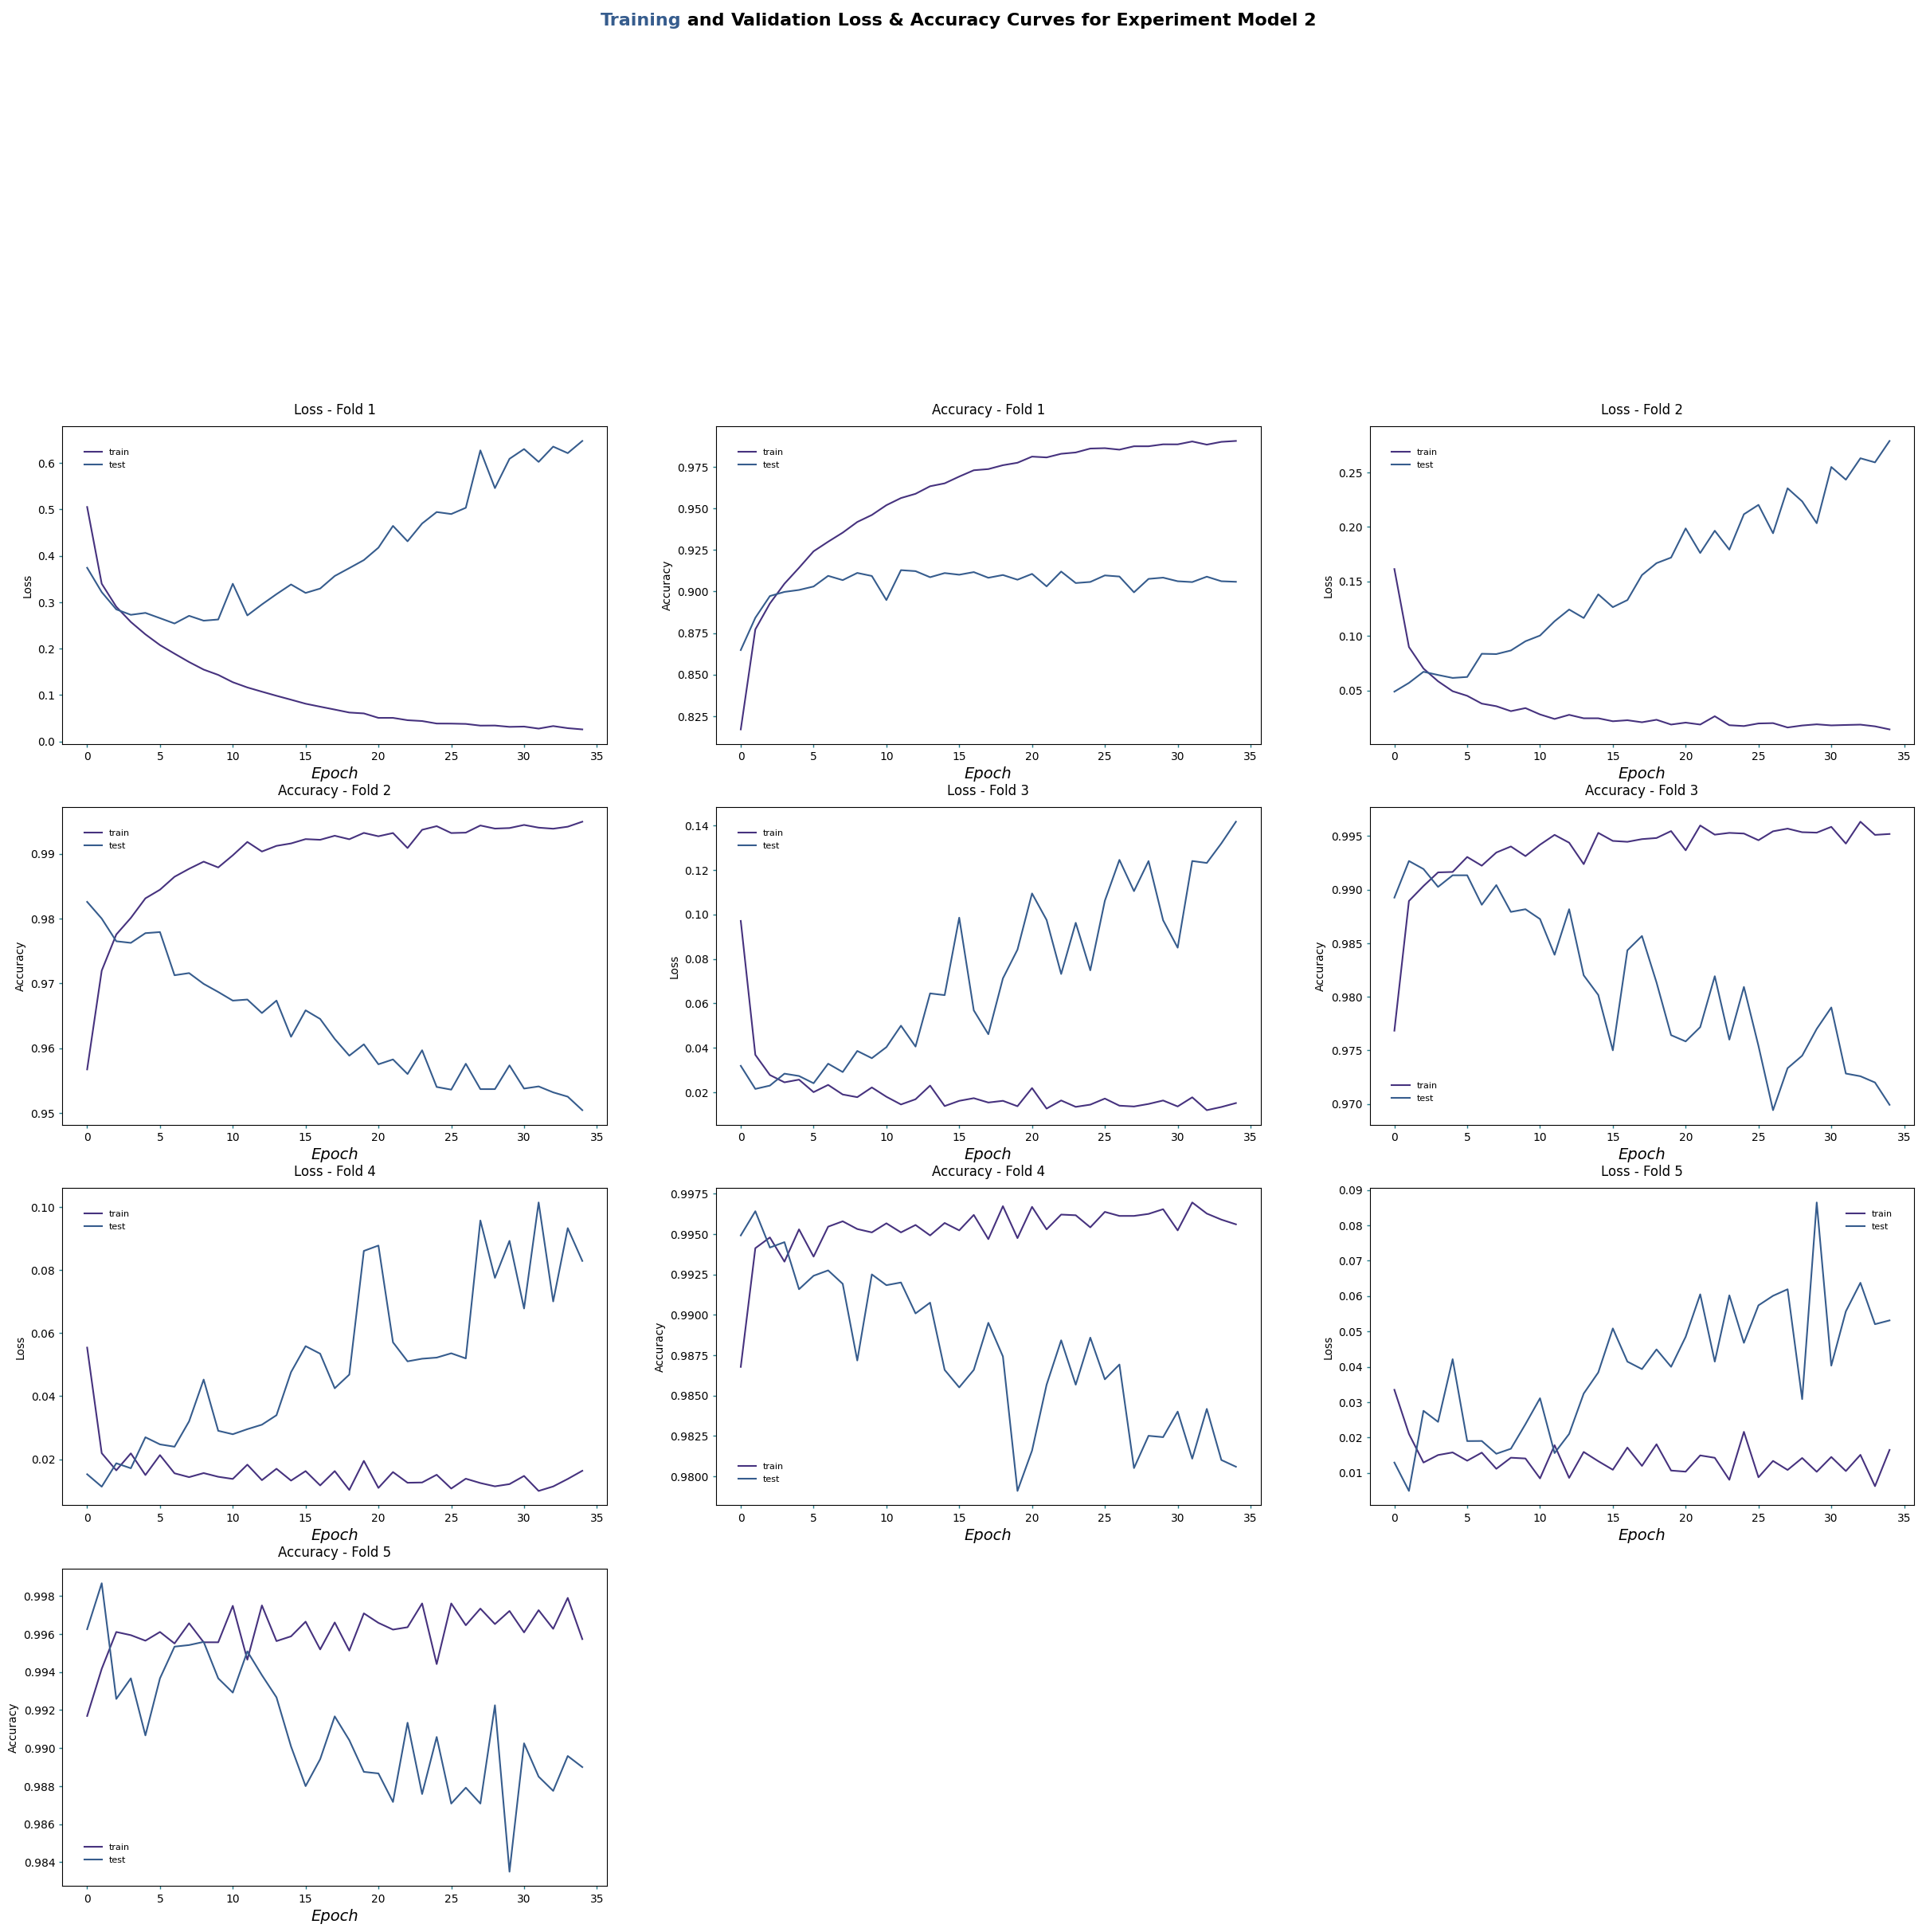

In [40]:
# --- Loss & Accuracy Curves: Experiment Model 2 Settings ---

cols = 3


rows = 5

# Configuración del estilo del texto que se usará en el eje X de las gráficas.
xlabel = dict(fontsize=14, style='italic', loc='center')


tick_params = dict(length=3, width=1, color=color_line)


legend_style = dict(borderpad=2, frameon=False, fontsize=8)


suptitle = dict(x=0.5, y=1.05, fontsize=16, weight='bold', ha='center', va='center')

# Estilo del subtítulo que indica el nombre del modelo:
model_style = dict(x=0.5, y=1.03, fontsize=12, ha='center', va='center')

# highlight_textprops = [
#     {'weight': 'bold', 'color': colors[4]}
# ]

# # Para el subtítulo (dos fragmentos <shirts> y <t-shirts/top>)
# highlight_model = [
#     {'weight': 'bold', 'color': colors[4]},
#     {'weight': 'bold', 'color': colors[4]},   # estilo para <shirts>
#     {'weight': 'bold', 'color': colors[5]}    # estilo para <t-shirts/top>
# ]


suptitle_textprops = [

    {'weight': 'heavy', 'color': colors[1]},
    {'weight': 'heavy'}
]


highlight_model = [
    {'bbox': {'edgecolor': 'black', 'facecolor': 'black', 'pad': 1}, 'color': 'white'}
]


learning_curves(cols, rows, histories, "Experiment Model 2")


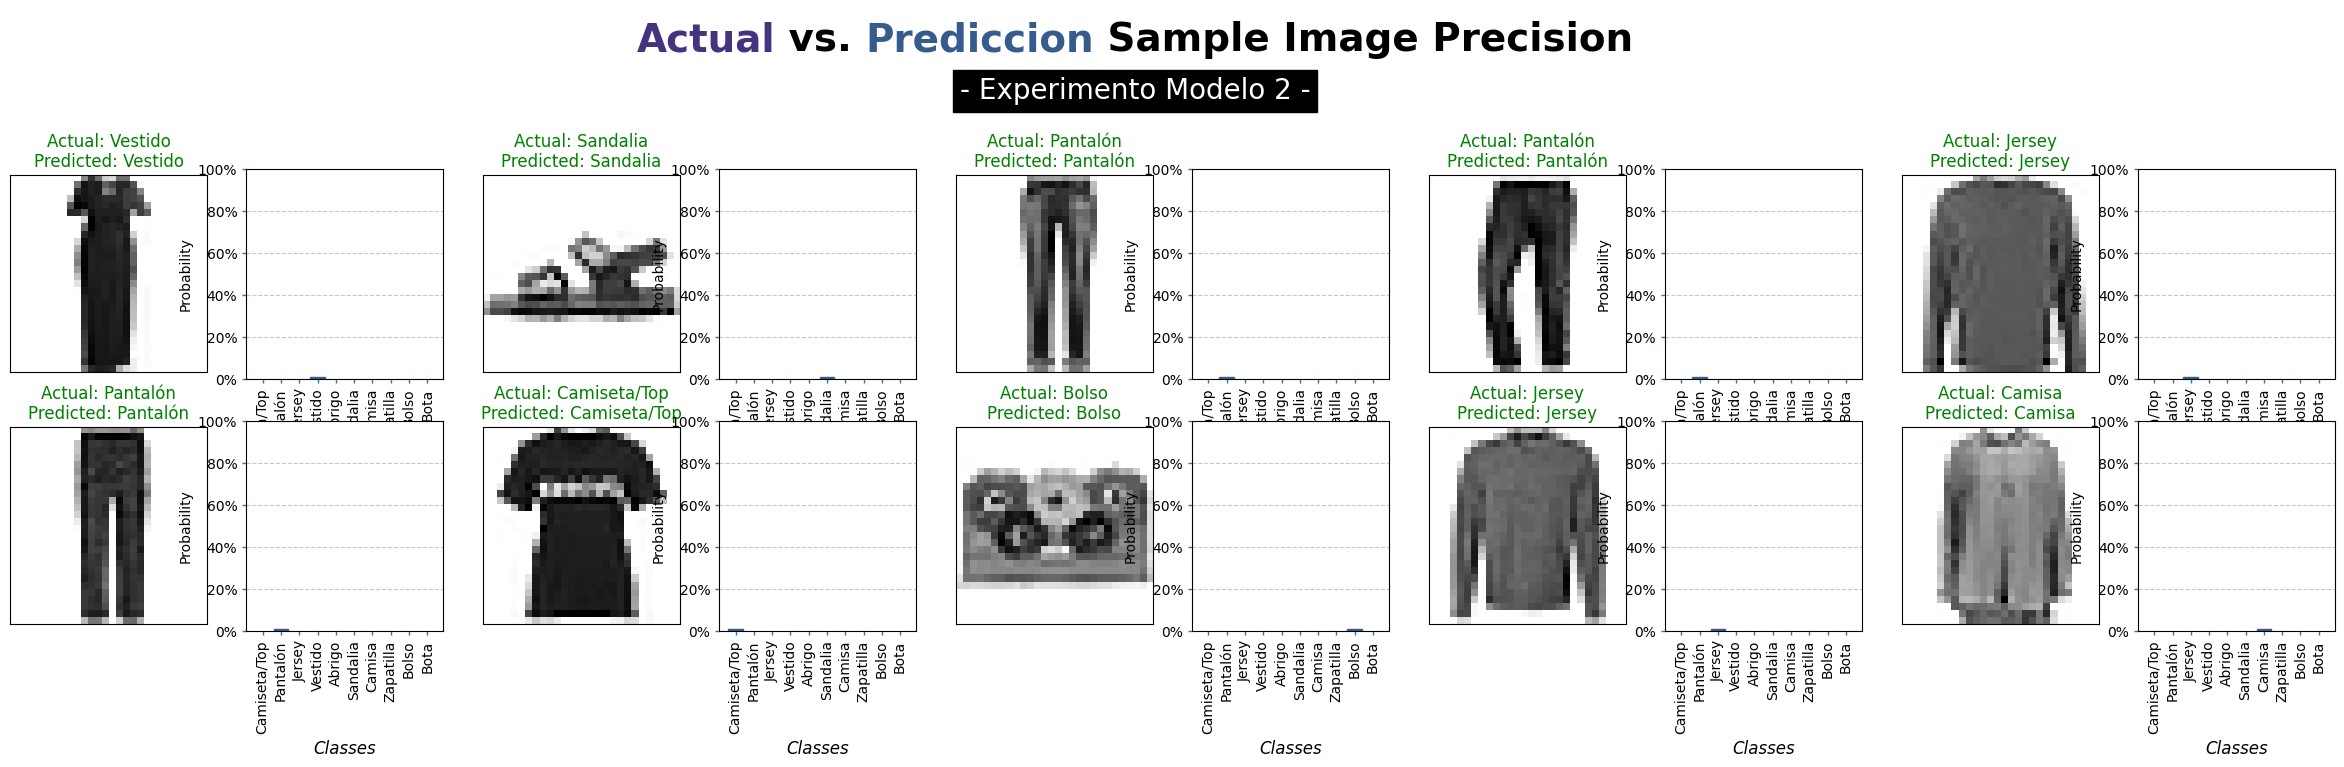

In [30]:
# --- Experiment Model 2 - Sample Image: Settings ---

cols = 5

rows = 2

imgs = rows * cols

y_ticks = list(np.arange(0, 120, 20))

y_labels = list(map(str, y_ticks))


y_labels = [lbl + "%" for lbl in y_labels]


xlabel = dict(fontsize=12, style='italic', loc='center')


suptitle_textprops = dict(x=0.5, y=1.1, fontsize=28, weight='bold', ha='center', va='center')


suptitle_model = dict(x=0.5, y=1.01, fontsize=20, ha='center', va='center')


highlight_textprops = [{'weight': 'heavy', 'color': colors[0]}, {'weight': 'heavy', 'color': colors[1]}]


highlight_model = [{'bbox': {'edgecolor': 'black', 'facecolor': 'black', 'pad': 5}, 'color': 'white'}]


plt.figure(figsize=(6*cols, 3*rows))

# Itera sobre la cantidad de imágenes a mostrar
for i in range(imgs):
    # Índice aleatorio seleccionado previamente en 'sample'
    num = sample[i]


    plt.subplot(rows, 2*cols, 2*i+1)
    plot_image(num)  # Función personalizada: dibuja la imagen con su etiqueta real y predicha

    # Subplot derecho del par: muestra la barra de probabilidades por clase
    plt.subplot(rows, 2*cols, 2*i+2)
    plot_value_array(num)  # Función personalizada: dibuja el histograma de probabilidades


fig_text(
    s='\n<Actual> vs. <Prediccion> Sample Image Precision',
    highlight_textprops=highlight_textprops,
    **suptitle_textprops
)

# Subtítulo identificando el bloque como perteneciente a "Experiment Model 2"
fig_text(s='<- Experimento Modelo 2 ->', highlight_textprops=highlight_model, **suptitle_model)


# Muestra la figura final en pantalla
plt.show();


In [31]:
# --- Experiment Model 2 Classification Report ---

y_preds = y_pred.argmax(axis=1)


y_tests = y_test.argmax(axis=1)


print(clr.start+'.:. Experiment Model 2 Classification Report .:.'+clr.end)


print(clr.color+'*'* 49+clr.end)

# Se genera e imprime el reporte de clasificación utilizando las etiquetas contenidas en fashion_list
print(classification_report(y_tests, y_preds, target_names=fashion_list))


.:. Experiment Model 2 Classification Report .:.
*************************************************
              precision    recall  f1-score   support

Camiseta/Top       0.84      0.86      0.85      1000
    Pantalón       1.00      0.98      0.99      1000
      Jersey       0.84      0.85      0.85      1000
     Vestido       0.89      0.92      0.91      1000
      Abrigo       0.86      0.85      0.86      1000
    Sandalia       0.98      0.97      0.98      1000
      Camisa       0.76      0.71      0.74      1000
   Zapatilla       0.95      0.97      0.96      1000
       Bolso       0.97      0.98      0.98      1000
        Bota       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



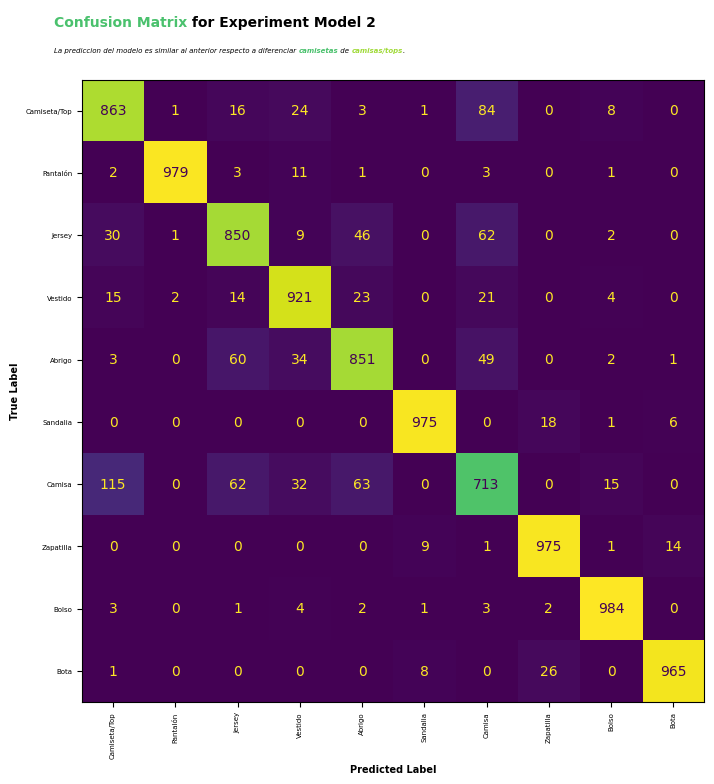

In [37]:
# --- Experiment Model 2 - Conf. Matrix: Settings ---

conf_mtx_style = dict(cmap=cmap_list[1], colorbar=False)


suptitle = dict(x=0.12, y=0.95, fontsize=10, weight='heavy', ha='left', va='bottom')


title = dict(x=0.12, y=0.92, fontsize=5, style='italic', weight='normal', ha='left', va='bottom')


xylabel = dict(fontsize=7, weight='bold')

highlight_textprops = [
    {'weight': 'bold', 'color': colors[4]}
]

# Para el subtítulo (dos fragmentos <shirts> y <t-shirts/top>)
highlight_model = [
    #{'weight': 'bold', 'color': colors[4]},
    {'weight': 'bold', 'color': colors[4]},   # estilo para <shirts>
    {'weight': 'bold', 'color': colors[5]}    # estilo para <t-shirts/top>
]

#highlight_textprops = [{'weight': 'bold'}, {'weight': 'bold', 'color': colors[4]}, {'weight': 'bold', 'color': colors[5]}]


lbl_size = 5

# --- Experiment Model 2 - Conf. Matrix ---

subtitle = "La prediccion del modelo es similar al anterior respecto a diferenciar <camisetas> de <camisas/tops>."

# Llamada a la función que grafica la matriz de confusión usando las predicciones reales y predichas
plot_confusion_matrix(y_preds, y_tests, "Experiment Model 2", subtitle)



# Comparación de: M1 vs M2

| Característica                   | Model 1 (Básico)  | Model 2 (Avanzado) |
| -------------------------------- | ----------------- | ------------------ |
| Profundidad                      | Baja              | Alta               |
| Filtros                          | Pocos             | Más                |
| Regularización                   | Dropout           | Dropout + extra    |
| BatchNorm                        | No (generalmente) | Sí                 |
| Capacidad para aprender detalles | Media             | Alta               |
| Riesgo de overfitting            | Medio             | Bajo-medio         |
| Objetivo                         | Baseline          | Modelo final       |



La evolución entre modelos es completamente justificada:

* Model 1 prueba que el dataset funciona.
* Model 2 demuestra mejoras reales con arquitectura más profunda y estable.


In [33]:
#Prueba

import cv2

def predict_my_image(path):
    # --- Load image ---
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("No se pudo cargar la imagen. Revisa el path.")

    # --- Resize to 28x28 ---
    img_resized = cv2.resize(img, (28, 28))

    # --- Normalize (0-1) ---
    img_norm = img_resized / 255.0

    # --- Expand dims: (28,28) → (28,28,1) ---
    img_input = np.expand_dims(img_norm, axis=-1)

    # --- Add batch dimension: (28,28,1) → (1,28,28,1) ---
    img_input = np.expand_dims(img_input, axis=0)

    # --- Predict ---
    preds = model_3.predict(img_input)   # usa tu modelo final
    label_id = np.argmax(preds)

    # --- Show image ---
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Predicción: {fashion_list[label_id]}")
    plt.axis('off')
    plt.show()

    return preds
